<a href="https://colab.research.google.com/github/jjww1024/BIOAI/blob/main/15_%E1%84%8B%E1%85%A8%E1%84%8C%E1%85%B5%E1%84%87%E1%85%A9%E1%84%89%E1%85%AE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 예제 15 예지보수 (Predictive Maintenance)

- **대상 설비:** 동결건조기(Lyophilizer) — 생물의약품 제조의 핵심 설비
- 머신러닝의 회귀 및 분류 예측 모델로 **고장까지 남은 배치 수(RUL: Remaining Useful Life)** 예측
- 신경망의 LSTM 모델 사용

### 보수의 종류

| 방식 | 설명 | 비용 | GMP 적합성 |
|------|------|------|------------|
| 사후 정비 | 고장 후 수리 | 예측 불가 (최고) | ❌ 생산 중단, 배치 손실 |
| 정기적 정비 | 일정 주기로 교체 | 높음 (과잉 교체) | ✅ GMP 기본 요구 |
| **AI 예지보수** | 상태 기반 최적 시점 정비 | **낮음 (최적)** | ✅✅ 데이터 기반 ICH Q10 |

## 머신러닝을 이용한 PM 예제

- 동결건조기 센서 데이터(압력, 온도, 진동, 전류 등)를 보고 **다음 정비까지 남은 배치 수**를 예측
- **회귀 모델**: "몇 배치 뒤에 고장?" (RUL 수치 예측)
- **분류 모델**: "앞으로 30배치 안에 고장이 날까?" (위험/안전 판정)


---
## 예지 보수(Predictive Maintenance)와 GMP

### 목표: "발효조 센서가 언제 고장 날지" 미리 예측
발효조 센서는 고장 나면 **공정 제어 불가능** → 배치 실패 → 거액의 손실 (항생제 배치당 수십만 달러)
따라서 **"고장 나기 전에 미리 교체"**하는 것이 중요합니다.

### 전통적 유지보수(Reactive vs Preventive)
```
[Reactive] 고장 → 긴급 수리 → 배치 손실 → 엄청난 비용
[Preventive] 정기적 교체 (예: 매 1,000시간) → 불필요한 교체도 많음
[Predictive] 센서 신호 분석 → "500시간 후 고장" 예측 → 딱 맞게 교체
```

### RUL (Remaining Useful Life) 예측
LSTM이나 Random Forest 모델로 센서의 **"앞으로 얼마나 정상 작동할지(시간)" 예측**합니다.
```
[센서 열화 신호 분석]
온도 센서 오차가 서서히 증가 중 (drift)
    ↓
[ML 모델]
"현재 추세대로면 500시간 후 오차가 ±5도 이상"
    ↓
[유지보수 스케줄]
400시간 후 센서 교체 (여유 보유)
```

### 🔒 GMP Compliance: CSV와 센서 Validation
21 CFR Part 11, EU GMP Annex 11에서는 센서의 **Validation 문서**를 요구합니다:
- **Accuracy**: ±오차범위가 얼마인가?
- **Drift**: 시간이 지나면서 오차가 누적되는가?
- **Maintenance Schedule**: 언제 교체해야 하는가?

예지 보수 모델은 바로 이 **"Maintenance Schedule 과학화"**입니다.

---

### 🏛️ GMP 커버리지
| 규정 / 가이드라인 | 이 예제에서의 적용 |
|----------------|-----------------|
| **EU GMP Annex 1 (2022 개정)** | 설비 유지보수 계획 수립 의무 → AI로 최적화 |
| **GAMP 5 (2nd Ed.)** | Category 4/5 소프트웨어 — 예지보수 AI 모델 검증 요구 |
| **21 CFR 211.67** | 설비 세척·유지보수 기록 → 고장 예측 학습 데이터 |
| **ICH Q10 지식 관리** | 설비 열화(Degradation) 패턴 = 공정 지식의 핵심 자산 |

### 🤖 AI 도입 장점
| 유지보수 방식 | 설명 | GMP 리스크 | AI 활용 |
|------------|------|----------|--------|
| **사후 보전** (Reactive) | 고장 후 수리 | 배치 손실, 오염 위험 | ✗ |
| **예방 보전** (Preventive) | 일정 주기 교체 | 과도한 교체 비용 | 주기 최적화 |
| **예지 보전** (Predictive) | AI로 고장 전 교체 | **최소 리스크** | **LSTM·RUL** |

### 🎯 핵심 Takeaway
> **"고장 후 수리 → 일정 교체 → AI 예측 교체 — 제약 설비 관리의 3단계 진화."**

1. **RUL(Remaining Useful Life)**: "지금 이 설비는 앞으로 몇 배치를 더 버틸 수 있는가?"  
   → 회귀 문제로 구현, LSTM이 시간 의존적 열화 패턴을 가장 잘 포착
2. 동결건조기 1대 고장 = 수십억 원 규모 생물의약품 배치 손실  
   → 예지보수 AI 1개 모델의 ROI가 즉각적으로 계산 가능 → **투자 정당화 용이**
3. 센서 데이터 21개 × 시간 × 100대 = 수백만 행 → **빅데이터 처리**가 필수  
   → pandas + numpy 벡터화 연산이 for loop 대비 수십 배 빠름


## PM 회귀 모델
- TTF(time to fail): 고장까지 남은 시간을 예측하는 회귀 모델로 구현
<img src="https://github.com/data-labs/image/blob/main/%E1%84%89%E1%85%B3%E1%84%8F%E1%85%B3%E1%84%85%E1%85%B5%E1%86%AB%E1%84%89%E1%85%A3%E1%86%BA%202021-02-15%20%E1%84%8B%E1%85%A9%E1%84%92%E1%85%AE%2010.02.12.png?raw=1" align='center'>

## PM 분류 모델 (이진 분류)
- U (Unsafe): TTF가 주어진 경계치 이하로 낮은 위험한 상태
- U 값이 0/1을 갖는 이진 분류 모델로 구현
<img src="https://github.com/data-labs/image/blob/main/%E1%84%89%E1%85%B3%E1%84%8F%E1%85%B3%E1%84%85%E1%85%B5%E1%86%AB%E1%84%89%E1%85%A3%E1%86%BA%202021-02-15%20%E1%84%8B%E1%85%A9%E1%84%92%E1%85%AE%2010.03.35.png?raw=1" align='left'>

# 데이터 준비

- **합성 데이터:** 동결건조기 100대의 센서 모니터링 + 고장시점 정보 (실제 정보는 아님!)
- 훈련 데이터: 각 설비의 **가동 시작(배치 1)부터 고장까지** 전체 이력
- 테스트 데이터: 각 설비의 가동 데이터만 (고장 전 특정 시점에서 중단)
- 정답(truth): 테스트 데이터 이후 각 설비의 잔여 유효 배치 수

## 동결건조기 센서 구성 (21개) - 예시임!

| 그룹 | 센서 | 설명 |
|-----|------|------|
| 운전 조건 | setting1~3 | 진공 목표 압력, 냉각 속도, 선반 온도 설정 |
| 진공계 | s2, s3 | 챔버 압력, 진공 펌프 오일 온도 |
| 냉동계 | s4, s5, s8, s9, s12, s17 | 콘덴서 온도, 냉매 유량/압력, 열교환 효율 |
| 기계계 | s6, s7, s11, s14, s20 | 진동, 전류, 실링 온도, 벨로우즈 마모 |
| 품질계 | s13, s15, s21 | 배기 유량, 밸브 개도, 오일 오염도 |
| 안정 센서 | s1, s10, s16, s18, s19 | 열화와 무관 → 분석 시 제외 |

## 훈련 데이터 구조


## 💻 [셀 설명] 동결건조기 합성 데이터 구조

### 실제 현장 적용 시 데이터 수집 방법
```
동결건조기 → IoT 센서 (21개) → SCADA/MES → 데이터 레이크 → ML 모델
```

### 데이터 컬럼 설명
| 컬럼 | 의미 | 단위 |
|------|------|------|
| **id** | 동결건조기 설비 번호 | 1~100 |
| **cycle** | 배치 번호 (가동 횟수) | 정수 |
| **setting1** | 진공 목표 압력 설정 | mbar |
| **setting2** | 냉각 속도 설정 | °C/min |
| **setting3** | 선반 온도 상한 설정 (안정) | °C |
| **s1** | 챔버 내부 온도 (안정) | °C |
| **s2** | 챔버 압력 (열화 시 증가) | mbar |
| **s3** | 진공 펌프 오일 온도 (열화 시 증가) | °C |
| **s4** | 콘덴서 입구 온도 (열화 시 증가) | °C |
| **s7** | 진공 펌프 전류 (열화 시 증가) | A |
| **s12** | 냉각 효율 지수 (열화 시 감소) | W/m²K |
| **s20** | 벨로우즈 마모 지수 (열화 시 증가) | — |
| **s21** | 오일 오염도 (열화 시 증가) | — |
| ... | (21개 센서 전체) | |

### 데이터 생성 전략
- **정상 구간**: 열화 없이 정상 운전 값 유지
- **열화 구간**: 고장이 가까워질수록 일부 센서가 점진적으로 악화(Drift)
- **고장**: 설비별 최대 수명(100~300 배치) 이후 고장 판정


In [ ]:
# 훈련 데이터, 테스트 데이터와 실제 정답 데이터
data_address = "https://raw.githubusercontent.com/StillWork/data/refs/heads/master/train_FD001.txt"
test_data_address = "https://raw.githubusercontent.com/StillWork/data/refs/heads/master/test_FD001.txt"
truth_data_address = "https://raw.githubusercontent.com/StillWork/data/refs/heads/master/RUL_FD001.txt"

import pandas as pd

df = pd.read_csv(data_address, sep=" ", header=None)
test_df = pd.read_csv(test_data_address, sep=" ", header=None)
truth_df = pd.read_csv(truth_data_address, sep=" ", header=None)

In [ ]:
# 훈련용 데이터
df.head()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN


In [ ]:
# 테스트 데이터

test_df[:3]

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,NaN,NaN
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,NaN,NaN
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,NaN,NaN


In [ ]:
truth_df

,0,1
0,112,NaN
1,98,NaN
2,69,NaN
3,82,NaN
4,91,NaN
...,...,...
95,137,NaN
96,82,NaN
97,59,NaN
98,117,NaN


In [ ]:
df.drop(df.columns[[26, 27]], axis=1, inplace=True)
df[:3]

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


In [ ]:
# 데이터 프레임의 정보 보기
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       20631 non-null  int64  
 1   1       20631 non-null  int64  
 2   2       20631 non-null  float64
 3   3       20631 non-null  float64
 4   4       20631 non-null  float64
 5   5       20631 non-null  float64
 6   6       20631 non-null  float64
 7   7       20631 non-null  float64
 8   8       20631 non-null  float64
 9   9       20631 non-null  float64
 10  10      20631 non-null  float64
 11  11      20631 non-null  float64
 12  12      20631 non-null  float64
 13  13      20631 non-null  float64
 14  14      20631 non-null  float64
 15  15      20631 non-null  float64
 16  16      20631 non-null  float64
 17  17      20631 non-null  float64
 18  18      20631 non-null  float64
 19  19      20631 non-null  float64
 20  20      20631 non-null  float64
 21  21      20631 non-null  int64  
 22

In [ ]:
# 변수명 지정
column_names = ['id', 'cycle', 'setting1', 'setting2', 'setting3', 's1', 's2', 's3',
                     's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14',
                     's15', 's16', 's17', 's18', 's19', 's20', 's21']
df.columns = column_names
df[:3]

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


## 고장 시점 레이블 추가
- 총 100개의 엔진에 대해서 각 엔진별로 고장나기 전까지의 데이터가 주어져 있다

### 레이블(y)  추가
- 회귀 분석에서는 잔여시간(TTF: time to fail, 또는 RUL: remaining useful lifetime)을 예측하며 각 상태(State) 값을 보고 앞으로 남은 잔여시간을 예측하는 회귀 모델을 만든다
- 분류 분석에서는 앞으로 특정 기간 이내에 고장 날지 여부를 예측한다. 예를 들어 30 사이클 이내에 고장 여부를 분류한다 (0/1 구분)
- 회귀 및 분류를 위한 레이블을 각각 만들겠다

### RUL(Remaining Useful Life)
  - 같은 엔진 ID에 대해서 최대 cycle 값이 "수명"을 나타낸다
  - 이 수명값을 rul 데이터프레임에 저장한다
  - 같은 엔진들 즉 같은 'id'를 같는 샘플들을 별도의 데이터프레임으로 만드는 groupby를 사용한다

In [ ]:
df[185:195]

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
185,1,186,0.0027,-0.0003,100.0,518.67,643.51,1595.16,1426.30,14.62,...,520.08,2388.25,8123.45,8.5227,0.03,397,2388,100.0,38.47,23.0564
186,1,187,-0.0047,-0.0000,100.0,518.67,643.32,1592.10,1427.27,14.62,...,519.53,2388.28,8115.67,8.5218,0.03,396,2388,100.0,38.42,23.0822
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,519.79,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,519.58,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,520.04,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,519.57,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,520.08,2388.32,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649
192,2,1,-0.0018,0.0006,100.0,518.67,641.89,1583.84,1391.28,14.62,...,522.33,2388.06,8137.72,8.3905,0.03,391,2388,100.0,38.94,23.4585
193,2,2,0.0043,-0.0003,100.0,518.67,641.82,1587.05,1393.13,14.62,...,522.70,2387.98,8131.09,8.4167,0.03,392,2388,100.0,39.06,23.4085
194,2,3,0.0018,0.0003,100.0,518.67,641.55,1588.32,1398.96,14.62,...,522.58,2387.99,8140.58,8.3802,0.03,391,2388,100.0,39.11,23.4250


## 💻 [셀 설명] RUL(잔여수명) 레이블 생성 — 핵심 개념

**RUL = Remaining Useful Life (잔여 유효 수명)**

이 셀들이 하는 일: 각 설비별로 "지금으로부터 고장까지 몇 배치 남았는지"를 계산합니다.

### RUL 계산 방법
```
동결건조기 #1의 최대 수명: 192 배치
    → 1번째 배치 기록: RUL = 192 - 1 = 191  (고장까지 191배치 남음)
    → 100번째 배치:    RUL = 192 - 100 = 92
    → 191번째 배치:    RUL = 192 - 191 = 1   (고장 1배치 전!)
    → 192번째 배치:    RUL = 0               (고장!)
```

### 제약 설비에서 RUL의 의미
| 설비 | RUL 의미 | 실무 활용 |
|------|---------|----------|
| **동결건조기** | 진공 펌프 정비까지 남은 배치 수 | 정비 일정 계획 |
| 정제 압착기 | 펀치/다이 교체까지 남은 생산량 | 예비 부품 발주 |
| 멸균기 | 개스킷 교체까지 남은 사이클 | GMP 설비 적격성 재확인 일정 |

### GMP Qualification과 RUL의 연결
- **IQ/OQ/PQ**: 설비 설치·운전·성능 적격성 확인 → RUL 기반 재검증 시점 결정
- **ICH Q10**: 예지보수를 지식 관리(Knowledge Management)의 일환으로 권장
- **FDA 21 CFR Part 11**: 전자 기록으로 정비 이력 관리 필수


- 판다스의 그룹바이 사용
- 100개 엔진별 데이터프레임을 내부적으로 만든다

In [ ]:
g = df.groupby('id')
g

In [ ]:
# 그룹바이 객체에 포함된 내부 그룹의 갯수 (엔진의 id 값이 100 종류임)
g.ngroups

100

In [ ]:
# id가 1인 그룹 보기

g.get_group(1)

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,519.79,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,519.58,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,520.04,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,519.57,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295


In [ ]:
# "cycle" 컬럼 내용 보기
g.get_group(1)['cycle']

0        1
1        2
2        3
3        4
4        5
      ... 
187    188
188    189
189    190
190    191
191    192
Name: cycle, Length: 192, dtype: int64

In [ ]:
g.get_group(1)['cycle'].max()

192

In [ ]:
# 100개 엔진 각각의 RUL 구하기

df.groupby('id')['cycle'].max()

,cycle
id,
1,192
2,287
3,179
4,189
5,269
...,...
96,336
97,202
98,156


In [ ]:
# 위의 결과를 데이터프레임으로 만들기
pd.DataFrame(df.groupby('id')['cycle'].max())

,cycle
id,
1,192
2,287
3,179
4,189
5,269
...,...
96,336
97,202
98,156


In [ ]:
# 모든 행에 대해서 잔여수명 레이블 추가
# rul 데이터프레임을 만들고 최대 수명 컬럼명을 max라고 지정

rul = pd.DataFrame(df.groupby('id')['cycle'].max()).reset_index()
rul.columns = ['id', 'max']
rul

,id,max
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269
...,...,...
95,96,336
96,97,202
97,98,156
98,99,185


- 엔진 고장시점 추가
 - 고장 시점(max)에서 현재 cycle을 빼면 잔여수명(RUL)이 된다

In [ ]:
# 두개의 데이터프레임 합치기 merge
df = df.merge(rul, on=['id'], how='left')

In [ ]:
df[:3]

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,max
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192


In [ ]:
df['RUL'] = df['max'] - df['cycle']
df[:3]

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s14,s15,s16,s17,s18,s19,s20,s21,max,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189


In [ ]:
# max 컬럼은 필요없으므로 삭제한다

df.drop('max', axis=1, inplace=True)
df[:3]

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189


## 이진 분류용 레이블
- 이진분류를 위해서, 향후 30 사이클 이내에 고장이 날 지를 예측하는 이진 분류용 레이블을 만든다


## 💻 [셀 설명] W=30 윈도우 기반 이진 분류 레이블

**이 셀이 하는 일:** RUL ≤ 30 사이클이면 위험(label=1), 아니면 안전(label=0)으로 분류합니다.

### 왜 30 사이클을 임계값으로 사용하는가?
```
RUL > 30: label = 0 (안전 구간, 여유 있음)
RUL ≤ 30: label = 1 (위험 구간, 조치 필요!)
```
- 30 사이클 = 사전 정비를 완료할 수 있는 충분한 준비 시간
- 너무 작으면 → 준비 시간 부족 (FN 위험 ↑)
- 너무 크면 → 멀쩡한 설비를 너무 일찍 정비 (FP, 생산 손실)

### GMP ICH Q9 리스크 관리 관점
W=30 임계값 설정 = **리스크 기반 결정(Risk-Based Decision Making)**

```
고위험 설비(멸균기, 발효조 메인 교반기): W = 50~100 (안전 여유 크게)
    → GMP 규정 위반 리스크 > 생산 손실 리스크
저위험 설비(보조 펌프, 냉각기): W = 10~20 (경제성 고려)
    → 생산 손실 리스크 > 정비 지연 리스크
```

**PM_03 분류 실습의 Threshold 조정과 같은 개념!**


In [ ]:
# numpy 패키지를 np 이름으로 사용하겠다는 선언
# np.where() 함수는 조건이 맞으면 앞의 값을, 틀리면 뒤의 값을 선택하는 함수임

import numpy as np

w = 30
df['label'] = np.where(df['RUL'] <= w, 1, 0 )
df.head()

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s14,s15,s16,s17,s18,s19,s20,s21,RUL,label
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189,0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188,0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187,0


In [ ]:
# 두번째 엔진 데이터가 시작하는 부분 보기

df[185:195]

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s14,s15,s16,s17,s18,s19,s20,s21,RUL,label
185,1,186,0.0027,-0.0003,100.0,518.67,643.51,1595.16,1426.30,14.62,...,8123.45,8.5227,0.03,397,2388,100.0,38.47,23.0564,6,1
186,1,187,-0.0047,-0.0000,100.0,518.67,643.32,1592.10,1427.27,14.62,...,8115.67,8.5218,0.03,396,2388,100.0,38.42,23.0822,5,1
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588,4,1
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127,3,1
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675,2,1
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295,1,1
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649,0,1
192,2,1,-0.0018,0.0006,100.0,518.67,641.89,1583.84,1391.28,14.62,...,8137.72,8.3905,0.03,391,2388,100.0,38.94,23.4585,286,0
193,2,2,0.0043,-0.0003,100.0,518.67,641.82,1587.05,1393.13,14.62,...,8131.09,8.4167,0.03,392,2388,100.0,39.06,23.4085,285,0
194,2,3,0.0018,0.0003,100.0,518.67,641.55,1588.32,1398.96,14.62,...,8140.58,8.3802,0.03,391,2388,100.0,39.11,23.4250,284,0


In [ ]:
# 특성 전체 리스트
features = ['setting1','setting2','setting3','s1','s2','s3','s4','s5','s6','s7','s8','s9','s10','s11','s12','s13','s14','s15','s16','s17','s18','s19','s20','s21']

# 각 특성의 값과 목적변수인 RUL과 상관계수를 본다

df[features].corrwith(df.RUL).sort_values(ascending=False)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,0
s12,6.719831e-01
s7,6.572227e-01
s21,6.356620e-01
s20,6.294285e-01
s16,-1.440037e-16
s5,-1.440037e-16
setting2,-1.947628e-03
setting1,-3.198458e-03
s6,-1.283484e-01
s14,-3.067689e-01



## 💻 [셀 설명] 센서 상관관계 분석 — 불필요한 특성 제거

**이 셀이 하는 일:** 21개 센서 중 목표변수(RUL)와 상관관계가 낮은 센서를 찾아 제거합니다.

### 왜 센서를 줄이는가?
- 21개 센서 중 일부는 RUL과 무관 → 오히려 모델 성능을 방해(노이즈)
- 특성이 적을수록 → 모델 단순, 빠름, 과적합 방지

### PAT에서 센서 선택의 의미
이 분석은 PAT 설계에서 **Critical Measurement(핵심 측정 대상)**를 결정하는 과정과 동일합니다:

```
[PAT 센서 선택 프로세스]
1단계: 모든 가능한 센서 설치 (탐색적 단계)
2단계: 상관관계 분석 → 핵심 CPP 센서 식별  ← 이 셀!
3단계: 핵심 센서만 운영 → 비용 절감 + 시스템 단순화
4단계: 온라인 PAT 시스템 구축
```

**GMP Annex 11 / 21 CFR Part 11:** 자동화된 센서 시스템은 **측정 범위, 정확도, 보정 이력**을 모두 문서화해야 합니다.


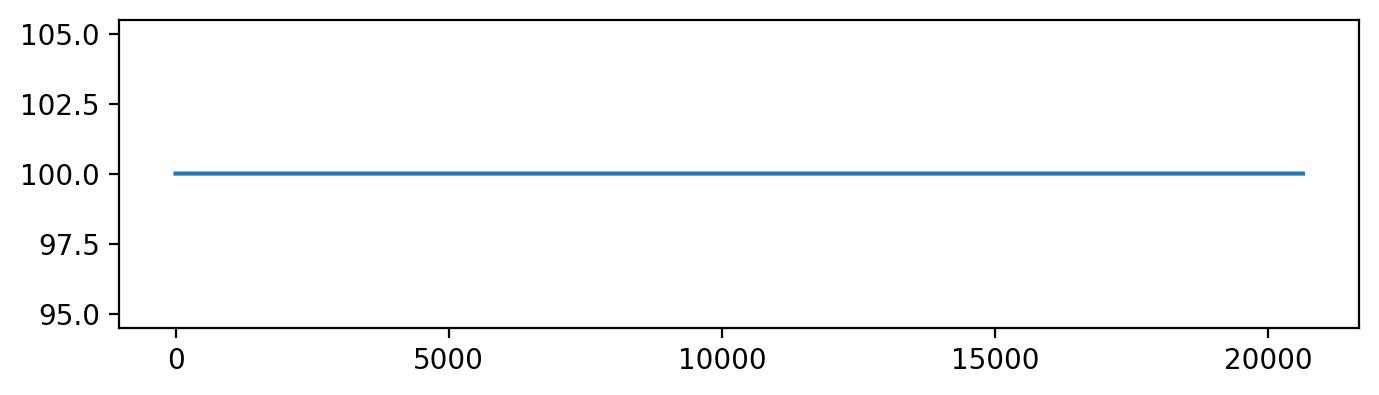

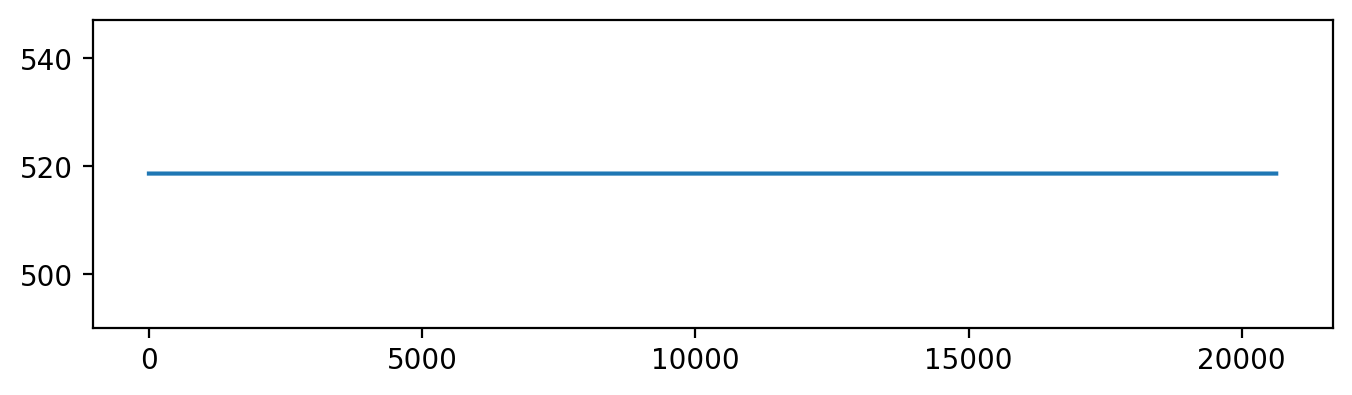

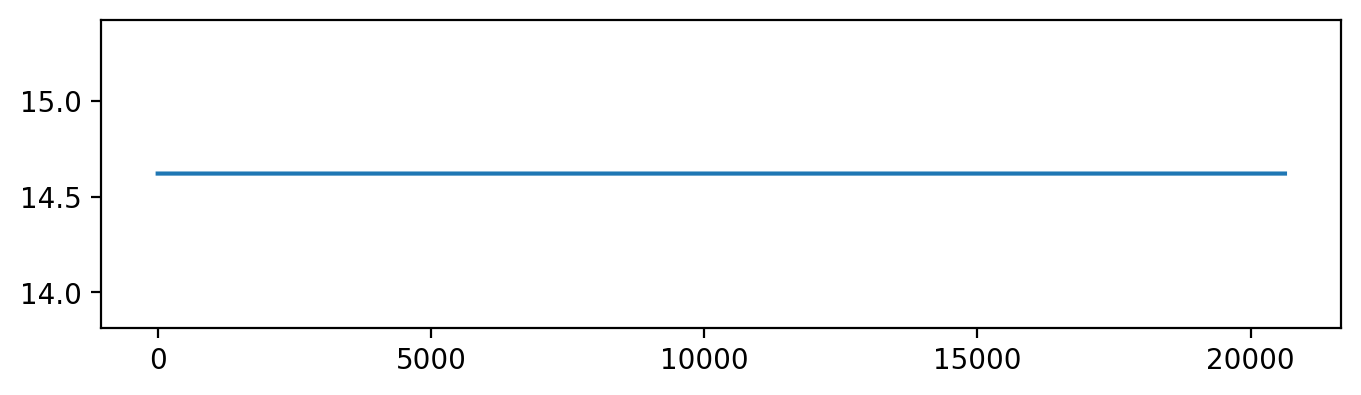

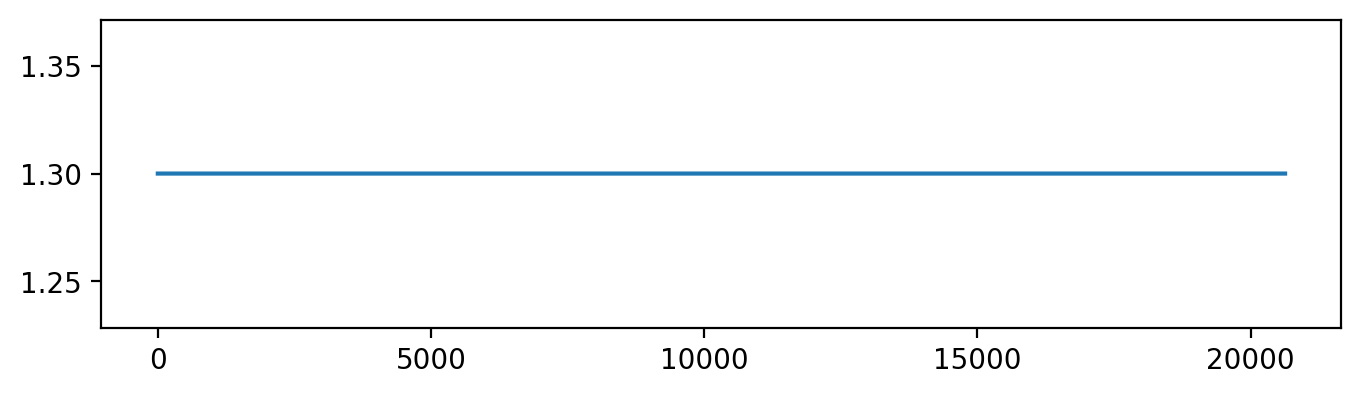

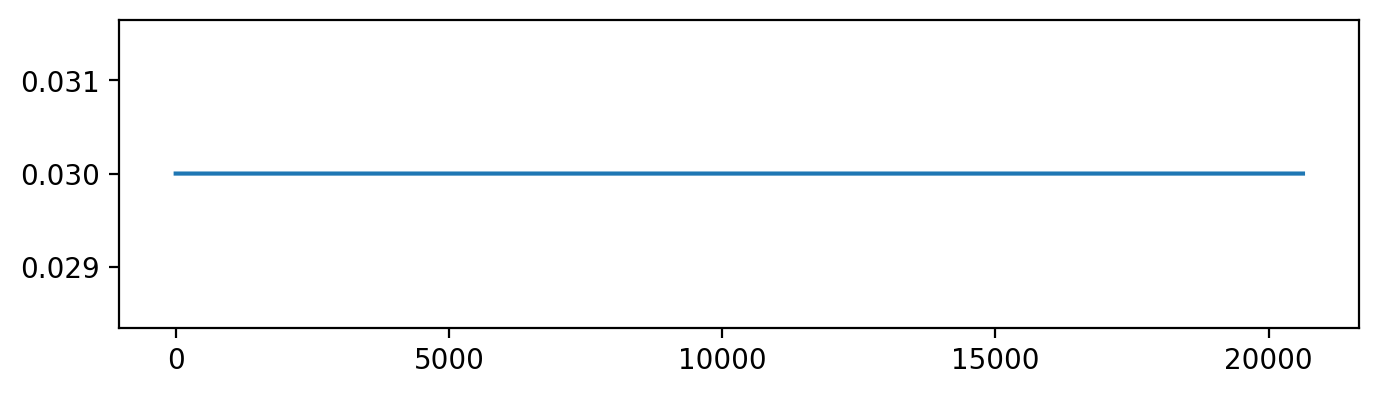

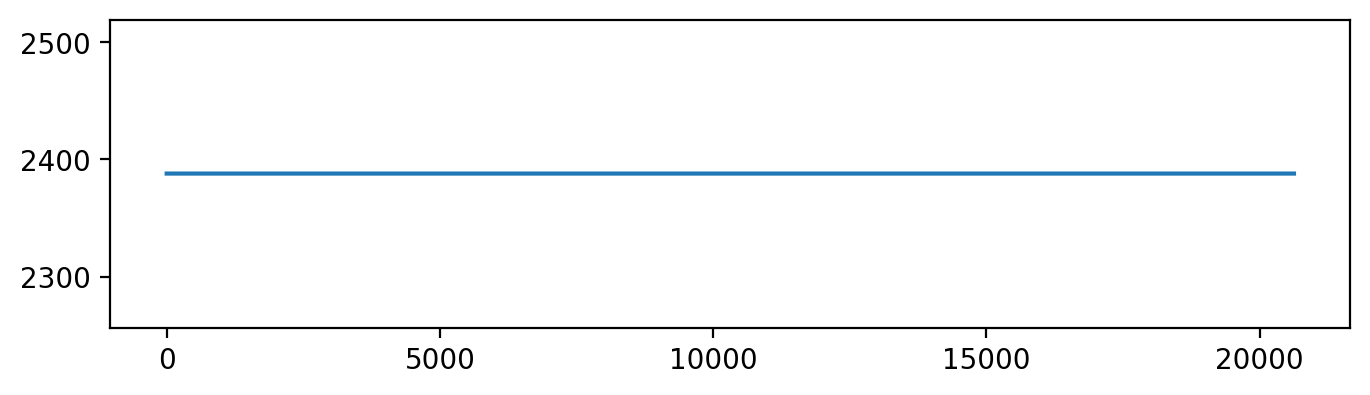

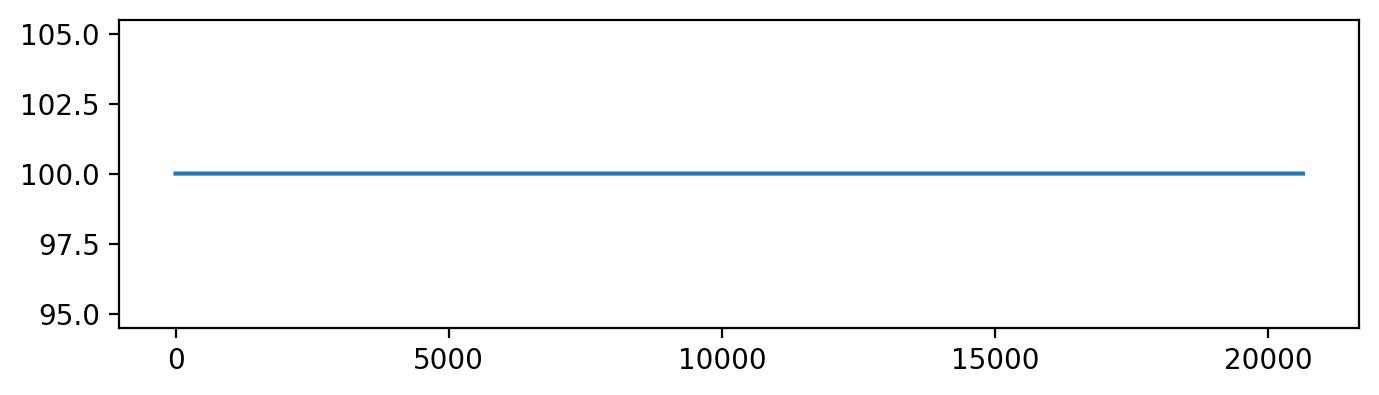

In [ ]:
# 상관계수가 적은 센서 값을 보겠다
# 파이썬의 그림 그리는 패키지
import matplotlib.pyplot as plt

# 레티나 디스플레이를 사용하는 경우 고화질로 출력해준다
%config InlineBackend.figure_format = 'retina'

# 아래 센서값을 시각화 하기
# 열화(Degradation)와 상관없이 일정한 센서 → 분석에서 제외
# s1(챔버 온도-안정), s5(콘덴서 출구-안정), s10(오일 점도-안정)
# s16(수분 누출율-안정), s18(냉매 충전량-안정), s19(도어 씰-안정), setting3(설정값-범주형)
discard = ['setting3','s1','s5','s10','s16','s18','s19']

# 아래 for문은, discard 리스트에서 하나씩 꺼내어 수행한다
for s in discard:
    plt.figure(figsize=(8, 2))
    df[s].plot()
    plt.show()

- 의미 없는 컬럼(특성)은 사용하지 않는다 (삭제한다)

In [ ]:
# df 에서 discard 리스트에 있는 "컬럼"들을 삭제한다 (axis=1)

df = df.drop(discard, axis=1)
df[:3]

,id,cycle,setting1,setting2,s2,s3,s4,s6,s7,s8,...,s11,s12,s13,s14,s15,s17,s20,s21,RUL,label
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,...,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191,0
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,...,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190,0
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,...,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189,0


In [ ]:
# 일부 센서 데이터만 사용하는 경우 - discard 내용을 제외한 것
features = ['setting1','setting2','s2','s3','s4','s6','s7','s8','s9','s11','s12','s13','s14','s15','s17','s20','s21']


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])
df[:3]

,id,cycle,setting1,setting2,s2,s3,s4,s6,s7,s8,...,s11,s12,s13,s14,s15,s17,s20,s21,RUL,label
0,1,1,-0.315980,-1.372953,-1.721725,-0.134255,-0.925936,0.141683,1.121141,-0.516338,...,-0.266467,0.334262,-1.058890,-0.269071,-0.603816,-0.781710,1.348493,1.194427,191,0
1,1,2,0.872722,-1.031720,-1.061780,0.211528,-0.643726,0.141683,0.431930,-0.798093,...,-0.191583,1.174899,-0.363646,-0.642845,-0.275852,-0.781710,1.016528,1.236922,190,0
2,1,3,-1.961874,1.015677,-0.661813,-0.413166,-0.525953,0.141683,1.008155,-0.234584,...,-1.015303,1.364721,-0.919841,-0.551629,-0.649144,-2.073094,0.739891,0.503423,189,0


## 테스트 데이터 전처리
- 훈련 데이터에 대한 전처리와 동일한 전처리를 테스트 데이터에 대해서도 수행해야 한다

In [ ]:
# test_df = pd.read_csv('http://azuremlsamples.azureml.net/templatedata/PM_test.txt', sep=" ", header=None)
test_df.drop(test_df.columns[[26, 27]], axis=1, inplace=True)
test_df.columns = ['id', 'cycle', 'setting1', 'setting2', 'setting3', 's1', 's2', 's3',
                     's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14',
                     's15', 's16', 's17', 's18', 's19', 's20', 's21']

In [ ]:
print(f"테스트 데이터: {test_df.shape}")
print(f"설비 수: {test_df['id'].nunique()}")
test_df[:3]

테스트 데이터: (13096, 26)
설비 수: 100


,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166


In [ ]:
# discard 컬럼 삭제 (테스트 데이터에도 동일하게 적용)
test_df = test_df.drop(discard, axis=1)
test_df[:3]

,id,cycle,setting1,setting2,s2,s3,s4,s6,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21
0,1,1,0.0023,0.0003,643.02,1585.29,1398.21,21.61,553.90,2388.04,9050.17,47.2,521.72,2388.03,8125.55,8.4052,392,38.86,23.3735
1,1,2,-0.0027,-0.0003,641.71,1588.45,1395.42,21.61,554.85,2388.01,9054.42,47.5,522.16,2388.06,8139.62,8.3803,393,39.02,23.3916
2,1,3,0.0003,0.0001,642.46,1586.94,1401.34,21.61,554.11,2388.05,9056.96,47.5,521.97,2388.03,8130.10,8.4441,393,39.08,23.4166


- 정답 데이터를 테스트 데이터에 추가하기 위해서 truth 정보를 이용한다


In [ ]:
truth_df

,0,1
0,112,NaN
1,98,NaN
2,69,NaN
3,82,NaN
4,91,NaN
...,...,...
95,137,NaN
96,82,NaN
97,59,NaN
98,117,NaN


In [ ]:
truth_df.drop(truth_df.columns[[1]], axis=1, inplace=True)

In [ ]:
truth_df

,0
0,112
1,98
2,69
3,82
4,91
...,...
95,137
96,82
97,59
98,117


In [ ]:
rul = pd.DataFrame(test_df.groupby('id')['cycle'].max()).reset_index()
rul.columns = ['id', 'max']
# truth_df[0] 컬럼에 각 설비의 잔여 배치 수가 저장되어 있습니다.
truth_df['id'] = truth_df.index + 1
truth_df['max'] = rul['max'] + truth_df[0]
truth_df.drop(0, axis=1, inplace=True)

# 각 행별로 잔여수명을 계산한다
test_df = test_df.merge(truth_df, on=['id'], how='left')
test_df['RUL'] = test_df['max'] - test_df['cycle']
test_df.drop('max', axis=1, inplace=True)
test_df.head()

# 분류를 위한 레이블 추가
test_df['label'] = np.where(test_df['RUL'] <= w, 1, 0 )
test_df.head()

,id,cycle,setting1,setting2,s2,s3,s4,s6,s7,s8,...,s11,s12,s13,s14,s15,s17,s20,s21,RUL,label
0,1,1,0.0023,0.0003,643.02,1585.29,1398.21,21.61,553.90,2388.04,...,47.20,521.72,2388.03,8125.55,8.4052,392,38.86,23.3735,142,0
1,1,2,-0.0027,-0.0003,641.71,1588.45,1395.42,21.61,554.85,2388.01,...,47.50,522.16,2388.06,8139.62,8.3803,393,39.02,23.3916,141,0
2,1,3,0.0003,0.0001,642.46,1586.94,1401.34,21.61,554.11,2388.05,...,47.50,521.97,2388.03,8130.10,8.4441,393,39.08,23.4166,140,0
3,1,4,0.0042,0.0000,642.44,1584.12,1406.42,21.61,554.07,2388.03,...,47.28,521.38,2388.05,8132.90,8.3917,391,39.00,23.3737,139,0
4,1,5,0.0014,0.0000,642.51,1587.19,1401.92,21.61,554.16,2388.01,...,47.31,522.15,2388.03,8129.54,8.4031,390,38.99,23.4130,138,0


### 스케일링 (주의)
- 훈련 데이터에 대해 수행한 스케일링과 동일한 조건을 테스트 데이터에 대해서도 적용해야 한다 (평균, 표준편차, 최소, 최대값 등)
- scaler.transform()을 사용해야 한다

In [ ]:
test_df[features] = scaler.transform(test_df[features])
test_df[:3]

,id,cycle,setting1,setting2,s2,s3,s4,s6,s7,s8,...,s11,s12,s13,s14,s15,s17,s20,s21,RUL,label
0,1,1,1.055599,1.015677,0.678077,-0.853550,-1.191480,0.141683,0.601408,-0.798093,...,-1.277396,0.415614,-0.919841,-0.954235,-0.985107,-0.781710,0.241943,0.774097,142,0
1,1,2,-1.230366,-1.031720,-1.941707,-0.338137,-1.501467,0.141683,1.674769,-1.220725,...,-0.154141,1.012195,-0.502695,-0.216648,-1.649034,-0.136018,1.127183,0.941305,141,0
2,1,3,0.141213,0.333211,-0.441831,-0.584426,-0.843717,0.141683,0.838677,-0.657216,...,-0.154141,0.754581,-0.919841,-0.715712,0.052112,-0.136018,1.459148,1.172256,140,0



# 탐색적 분석
### 시각화

- 여러 특성의 시계열 변화를 시각화해본다
- 특정 특성값에 대해서 임의의 엔진 데이터 보기

## 💻 [셀 설명] 센서 열화 신호 시각화 — Drift 탐지

**이 셀이 하는 일:** 동결건조기 센서들의 신호 변화를 시간(배치)에 따라 그려서
**"어떤 센서가 열화(Degradation)되고 있는가"** 시각적으로 확인합니다.

### 동결건조기 센서 열화 패턴

| 열화 패턴 | 센서 예시 | 신호 변화 | 의미 |
|---------|---------|---------|------|
| **Drift(점진적 상승)** | s2(챔버 압력), s7(전류) | 서서히 증가 | 진공 펌프 마모 |
| **Drift(점진적 하강)** | s12(냉각 효율), s8(냉매 유량) | 서서히 감소 | 냉동 시스템 열화 |
| **안정(Stable)** | s1, s5, s10, s16 | 거의 일정 | 정비 지표로 부적합 |
| **Spike(급격 변동)** | 고장 직전 일부 센서 | 갑작스러운 이상값 | 고장 임박 신호 |

→ Drift 패턴을 보이는 센서가 **RUL 예측에 중요한 특성**이 됩니다.


In [ ]:
import matplotlib.pyplot as plt

def plot_time_series(df, s, engines):
    for e in engines:
        plt.figure(figsize=(8, 2))
        df2 = df[['cycle', s]][df.id == e]
        plt.plot(df2['cycle'],df2[s])
        plt.show()

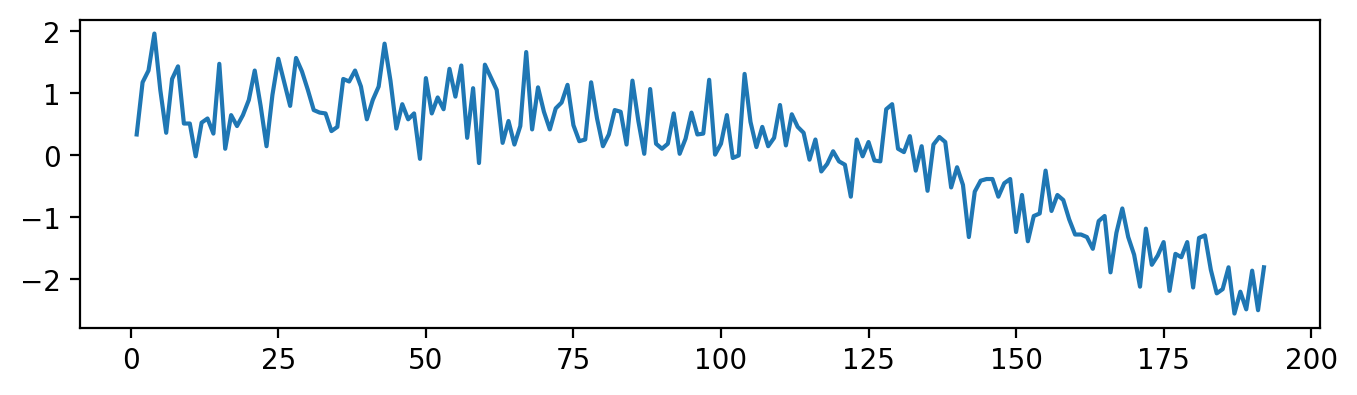

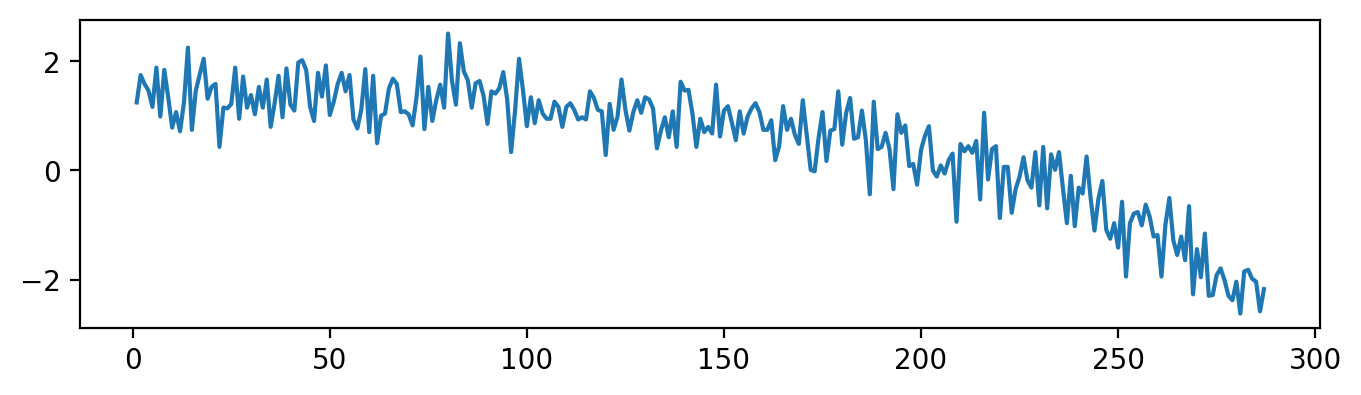

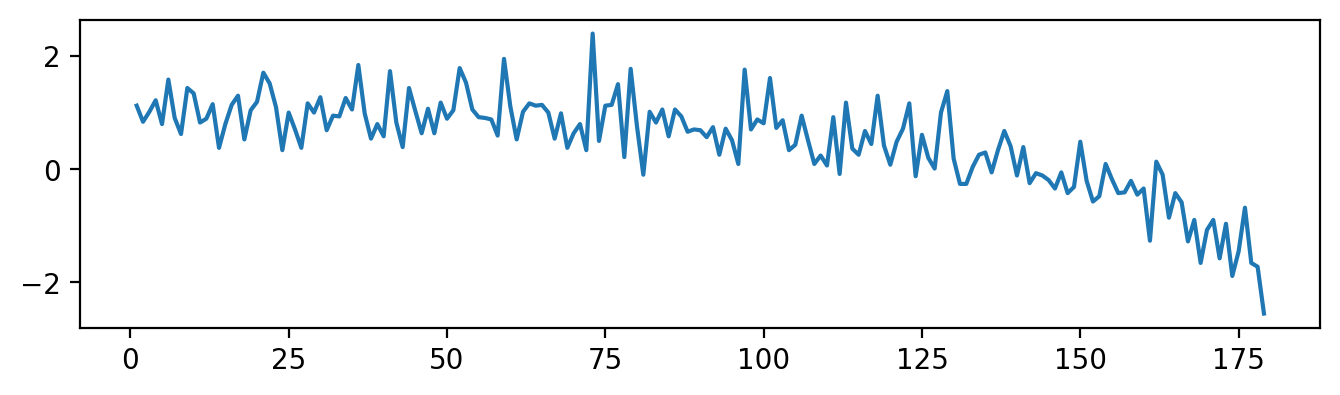

In [ ]:
# s12 센서 특성에 대해서 임의로 엔진 1, 2, 3의 값을 시각화

plot_time_series(df, 's12',[1,2,3])

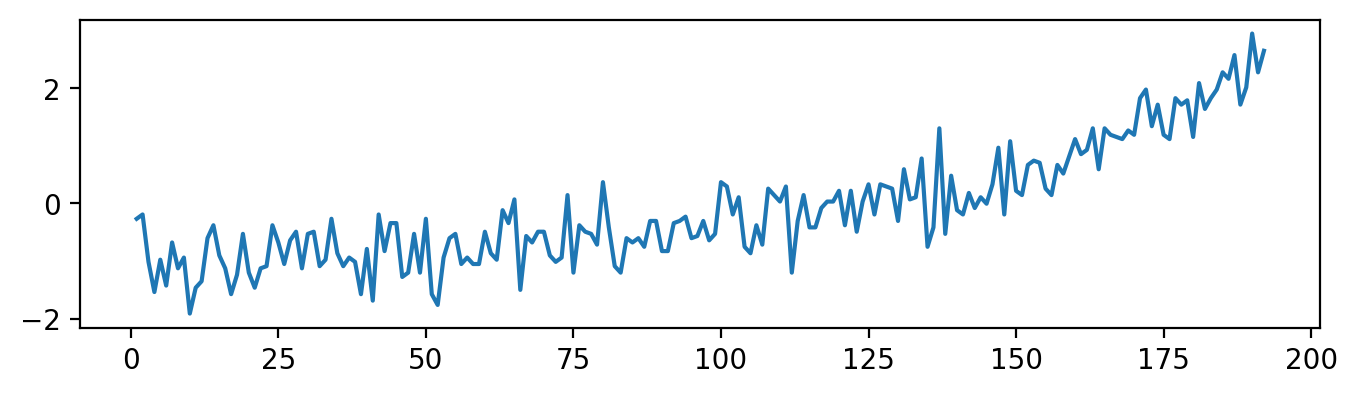

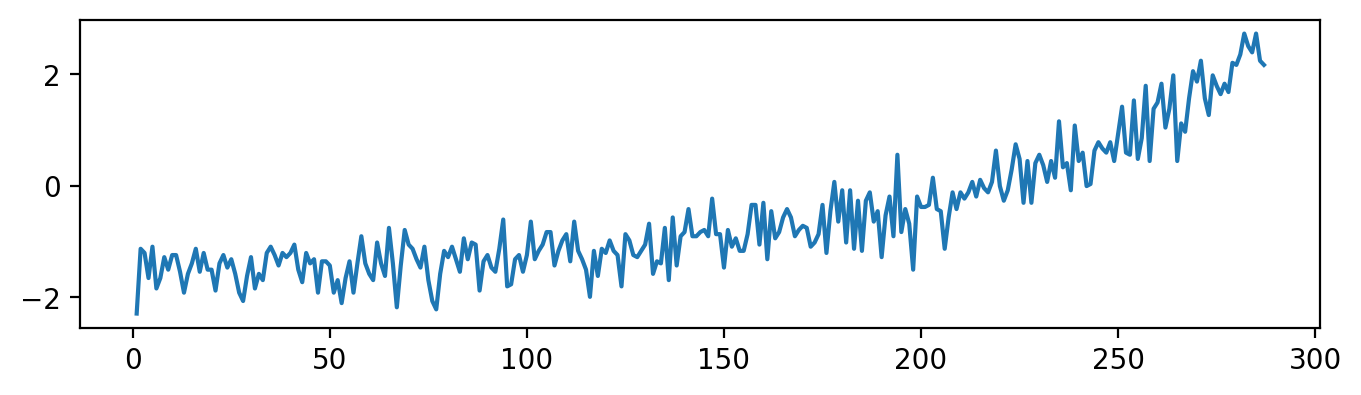

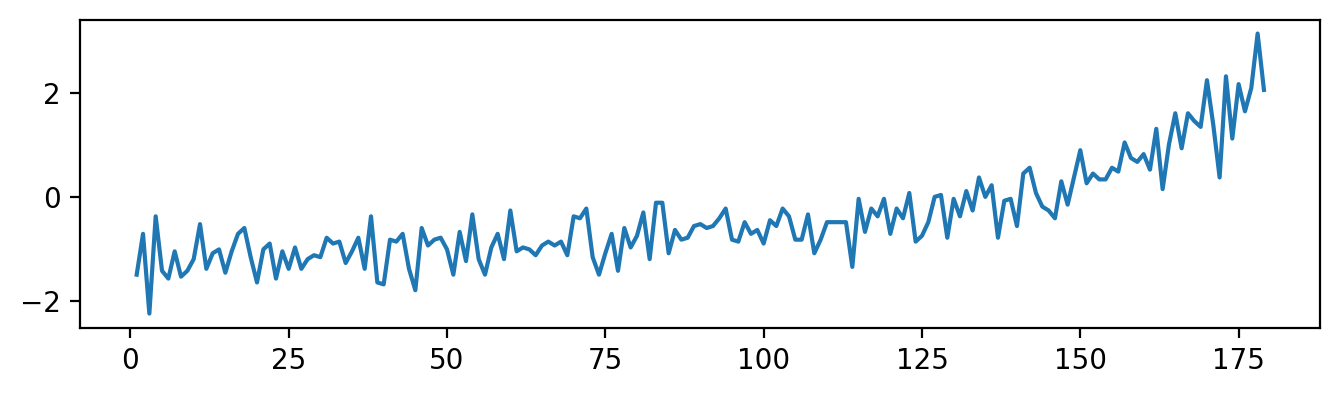

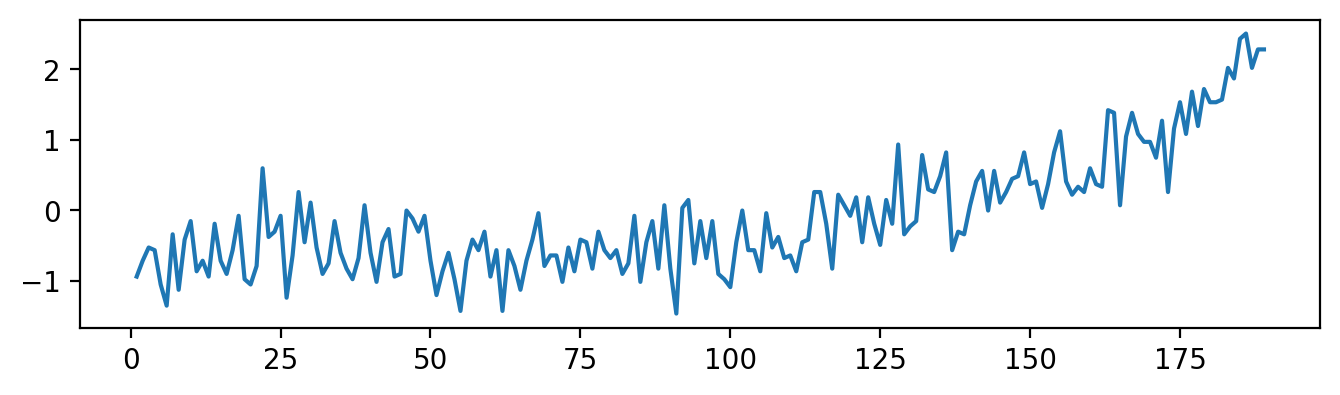

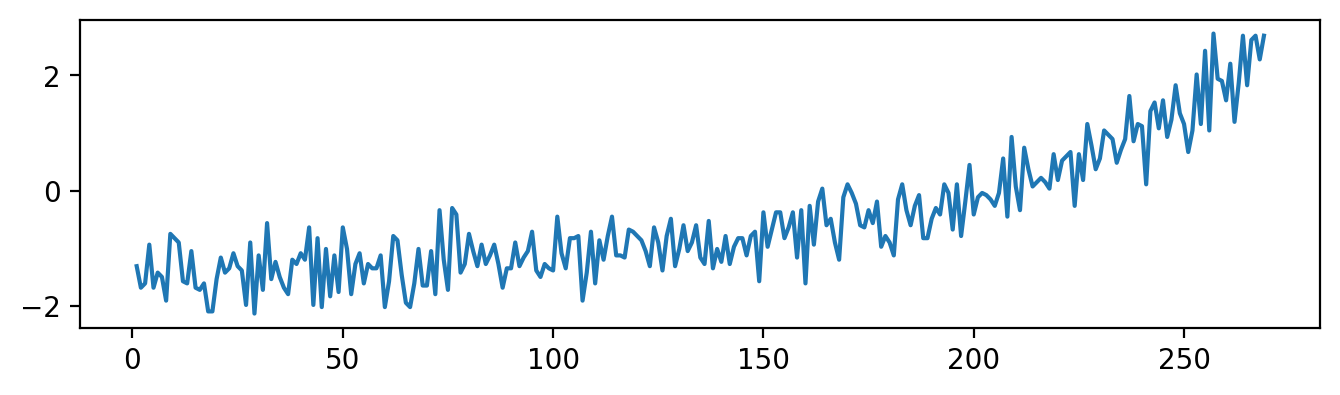

In [ ]:
# s11 센서 특성에 대해서 엔진 1, 2, 3, 4, 5의 값을 시각화

plot_time_series(df, 's11',[1,2,3,4,5])

# 머신러닝 모델 구현 절차

- (1) 훈련 및 테스트 데이터 준비
- (2) 머신러닝에서 사용할 모델 선택
- (3) 훈련 데이터를 사용하여 모델 학습 (최적의 파라미터를 구한다)
- (4) 테스트 데이터를 사용하여 모델의 성능 평가

# 회귀 모델
## 훈련 및 테스트 데이터 준비


## 💻 [셀 설명] 회귀 vs 분류 — 예지보수 모델 선택

**예지보수 문제는 두 가지 방식으로 접근할 수 있습니다:**

### 방법 1: 회귀(Regression) — "언제 고장나나?"
- **목표변수 y = RUL (숫자값)**: 고장까지 남은 사이클 수 예측
- 예: "이 엔진은 앞으로 47 사이클 더 운전 가능"
- **제약 현장 활용**: 발주, 생산 일정, 정비 계획에 구체적 수치 제공

### 방법 2: 분류(Classification) — "곧 고장나나?"
- **목표변수 y = label (0 또는 1)**: 30 사이클 이내 고장 여부
- 예: "이 엔진은 30 사이클 이내에 고장날 위험이 있음 (label=1)"
- **제약 현장 활용**: 즉각적인 경보(Alert) 시스템, 운전자 판단 지원

### GMP 관점: 어떤 모델을 선택해야 하나?
| 상황 | 권장 모델 | 이유 |
|------|----------|------|
| 설비 PM 일정 계획 | 회귀 모델 (RUL 예측) | 구체적 숫자로 계획 수립 |
| 실시간 안전 경보 | 분류 모델 (0/1) | 빠른 판단, 오경보 최소화 |
| **두 가지 다 필요** | **두 모델 병행** | **이 노트북처럼!** |


In [ ]:
# 훈련 데이터

X_train = df[features]
X_train

,setting1,setting2,s2,s3,s4,s6,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21
0,-0.315980,-1.372953,-1.721725,-0.134255,-0.925936,0.141683,1.121141,-0.516338,-0.862813,-0.266467,0.334262,-1.058890,-0.269071,-0.603816,-0.781710,1.348493,1.194427
1,0.872722,-1.031720,-1.061780,0.211528,-0.643726,0.141683,0.431930,-0.798093,-0.958818,-0.191583,1.174899,-0.363646,-0.642845,-0.275852,-0.781710,1.016528,1.236922
2,-1.961874,1.015677,-0.661813,-0.413166,-0.525953,0.141683,1.008155,-0.234584,-0.557139,-1.015303,1.364721,-0.919841,-0.551629,-0.649144,-2.073094,0.739891,0.503423
3,0.324090,-0.008022,-0.661813,-1.261314,-0.784831,0.141683,1.222827,0.188048,-0.713826,-1.539489,1.961302,-0.224597,-0.520176,-1.971665,-0.781710,0.352598,0.777792
4,-0.864611,-0.690488,-0.621816,-1.251528,-0.301518,0.141683,0.714393,-0.516338,-0.457059,-0.977861,1.052871,-0.780793,-0.521748,-0.339845,-0.136018,0.463253,1.059552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,-0.178822,-1.031720,1.618000,1.216258,2.188375,0.141683,-2.189329,1.315066,0.012547,1.980044,-2.607969,2.278282,-0.322542,1.425294,2.446751,-1.805173,-2.921113
20627,-0.727453,-1.714186,1.717992,2.279706,2.738351,0.141683,-2.833345,1.878576,-0.006020,1.867718,-2.350355,1.722087,-0.380207,1.913240,1.155367,-2.856395,-1.203764
20628,0.186933,-0.008022,1.478011,1.946971,2.138377,0.141683,-2.742957,2.019453,0.029755,2.054927,-1.902919,2.000184,-0.141684,3.265092,3.092444,-2.081810,-3.292481
20629,-0.498857,1.015677,1.098043,2.403666,1.955051,0.141683,-3.036719,2.160330,0.383884,3.178182,-2.363913,1.861136,-0.233948,2.579834,1.155367,-2.911722,-2.085072


- 회귀 분석을 하기 위해서 y 값으로 RUL을 사용한다

In [ ]:
y_train = df.RUL
y_train

,RUL
0,191
1,190
2,189
3,188
4,187
...,...
20626,4
20627,3
20628,2
20629,1


In [ ]:
# 테스트 데이터
X_test = test_df[features]
y_test = test_df['RUL']

## 선형 모델

In [ ]:
# 모델 선택, 학습, 예측

from sklearn.linear_model import LinearRegression
lin = LinearRegression()
lin.fit(X_train, y_train)
y_pred = lin.predict(X_test)

### 회귀 모델 성능 평가
- 회귀 모델의 성능을 평가하는 척도로 기본적으로 R-Squared를 사용하며 MAE, RMSE 등을 참고로 본다
 - MAE: mean absolute error  
 - MSE: mean squared error    
 - RMSE: root MSE  

$MAE = $$1\over{N}$$ \sum |y_{i} - \hat{y}|$

$MSE = $$1\over{N}$$ \sum (y_{i} - \hat{y})^{2}$

$RMSE = \sqrt{MSE}$

$R^{2} = 1$-$\sum(y_{i}-\hat{y})^{2}\over{\sum(y_{i}-\bar{y})^{2}}$ $= 1$-$MSE\over{Variance}$  
 >  $y$ :  실제값, $\hat{y}$ :  예측치, $\bar{y}$ :  평균치

-  R-Squared
 - 회귀 성능의 기본적인 평가 지표
 - MSE를 분산으로 정규화한 값을 사용한다
 - R-sqaured 값은 1에 가까울수록 완벽한 예측을 수행한 것이고, 0 근처이면 오차 평균치가 표준편차 정도인 경우이다

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score

def show_regression_result(y_test, y_pred, N=100):
    plt.rc('figure', figsize=(6,4))
    error = y_pred - y_test
    print("MAE=", np.abs(error).mean())
    print("rmse=", np.sqrt((error**2).mean()))
    print("max error=", max(abs(error)))
    print("R2=",r2_score(y_test, y_pred))

    if N > 0:
      plt.plot(y_test[:N], 'r.-', label='y_test')
      plt.plot(y_pred[:N], 'b.-', label='y_pred')
      plt.legend()
      plt.show()

MAE= 37.173906608879356
rmse= 48.39948399086452
max error= 219.468674794338
R2= 0.32655301945956694


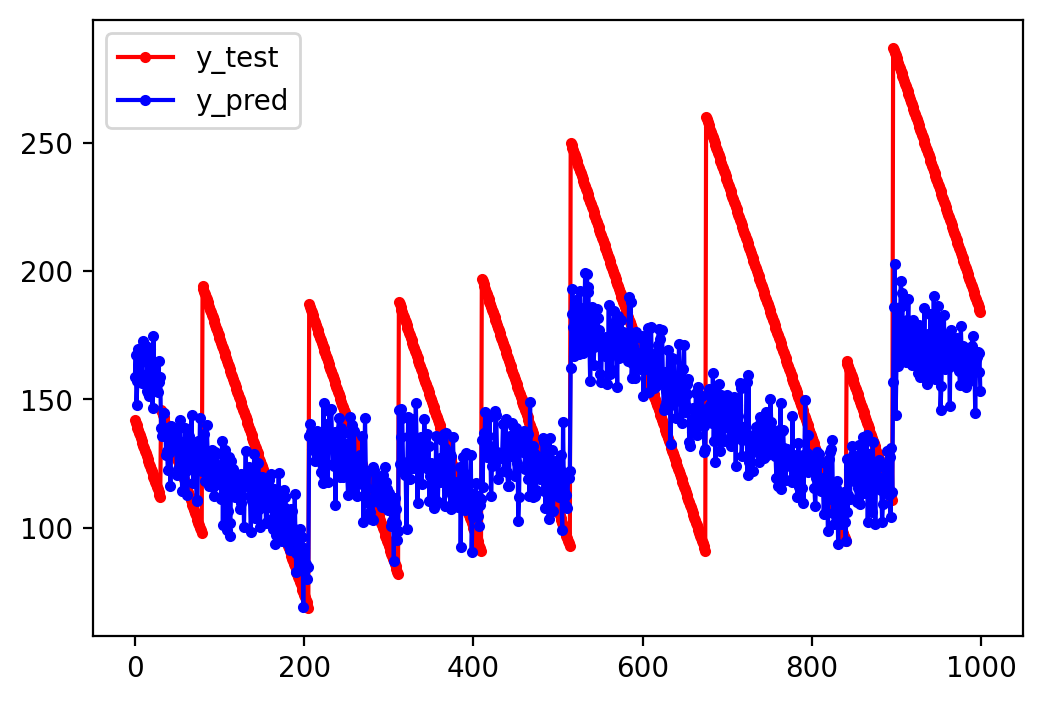

In [ ]:
# 선형 모델 성능 평가
show_regression_result(y_test, y_pred, 1000)

In [ ]:
# 선형 회귀 모델의 가중치(파라미터) 보기

lin.coef_

array([ 0.11185834,  0.45283509, -3.40902447, -2.70372301, -6.8838113 ,
       -0.7092495 ,  6.09098456, -0.93947937, -7.71864354, -9.93879351,
        7.83548153, -0.85322635, -5.22307351, -4.47833844, -2.86230807,
        3.58978195,  4.44713633])

In [ ]:
# 가중치를 그려 보는 함수 정의

def plot_features_weights(features, weights):

    W = pd.DataFrame({'Weights':weights}, index=features)
    W = W.sort_values(by='Weights', ascending=True)
    W.plot(kind='barh', figsize=(8, 6))

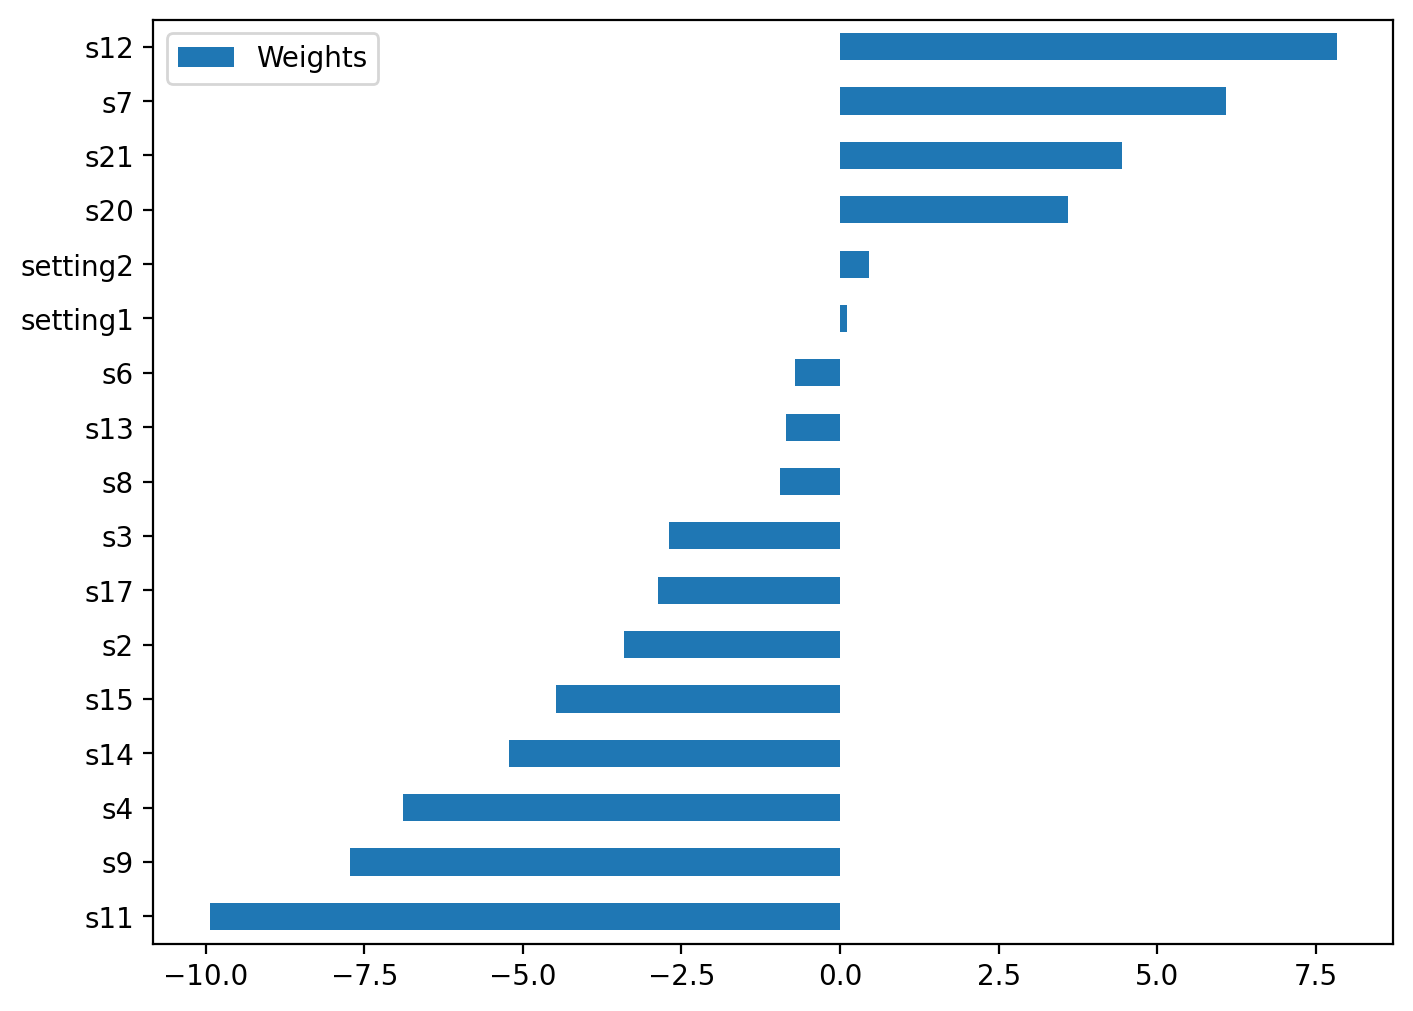

In [ ]:
# 선형 모델 가중치 보기
plot_features_weights(X_train.columns, lin.coef_)

## 트리 모델

In [ ]:
## 결정 트리를 이용한 이진 분류
# 트리의 깊이를 작게 선택하면 과소적합(under fitting)이 발생한다
# 트리의 깊이를 깊게 선택하면 과대적합(over fitting)이 발생한다

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

for depth in range(1,20):
    dtr = DecisionTreeRegressor(max_depth=depth)
    dtr.fit(X_train, y_train)
    print(depth, dtr.score(X_test, y_test))

1 0.06084562475195032
2 0.18931171832791283
3 0.2475274039073101
4 0.2829481758766963
5 0.31802730963674564
6 0.33554503867166596
7 0.3349522636270742
8 0.3324903242196796
9 0.3066201648069957
10 0.276132589019101
11 0.22439476995725327
12 0.15480189103729403
13 0.09408464601122113
14 0.034691597677685815
15 -0.049561654091255125
16 -0.09073277720664996
17 -0.14981512396923868
18 -0.1999286627468595
19 -0.23971405426666093


In [ ]:
# 최적의 깊이를 갖는 트리 모델

dtr = DecisionTreeRegressor(max_depth=6)
dtr.fit(X_train, y_train)
y_pred = dtr.predict(X_test)

MAE= 36.44470156775974
rmse= 48.07527760493368
max error= 220.90384615384616
R2= 0.33554503867166596


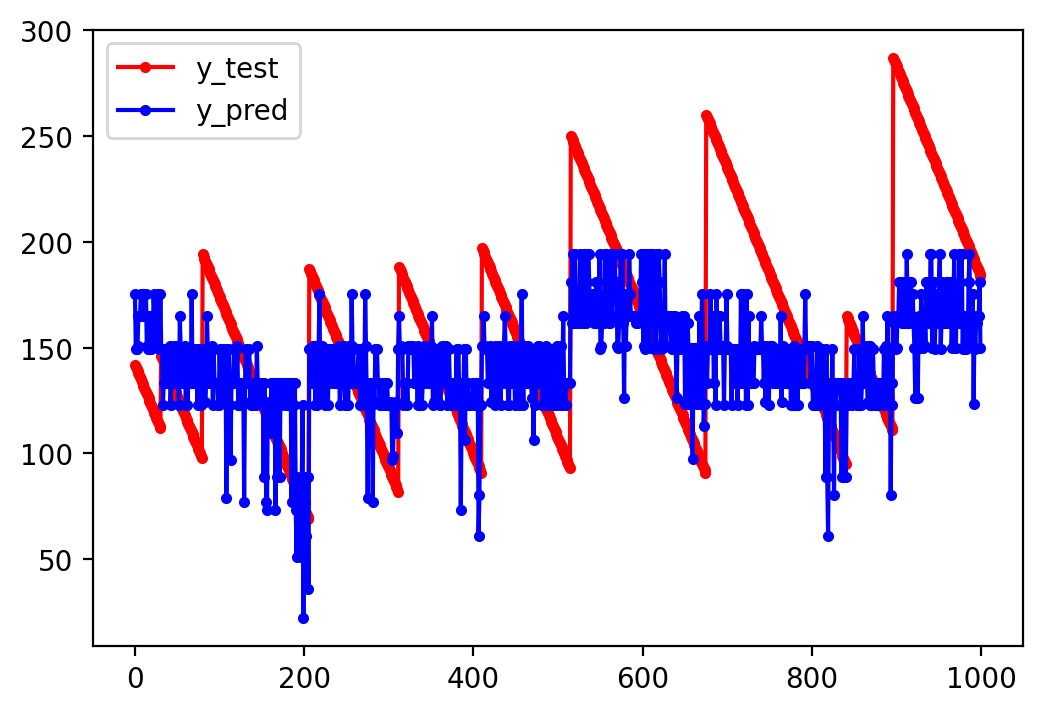

In [ ]:
# 트리 모델 성능 평가
show_regression_result(y_test, y_pred, 1000)

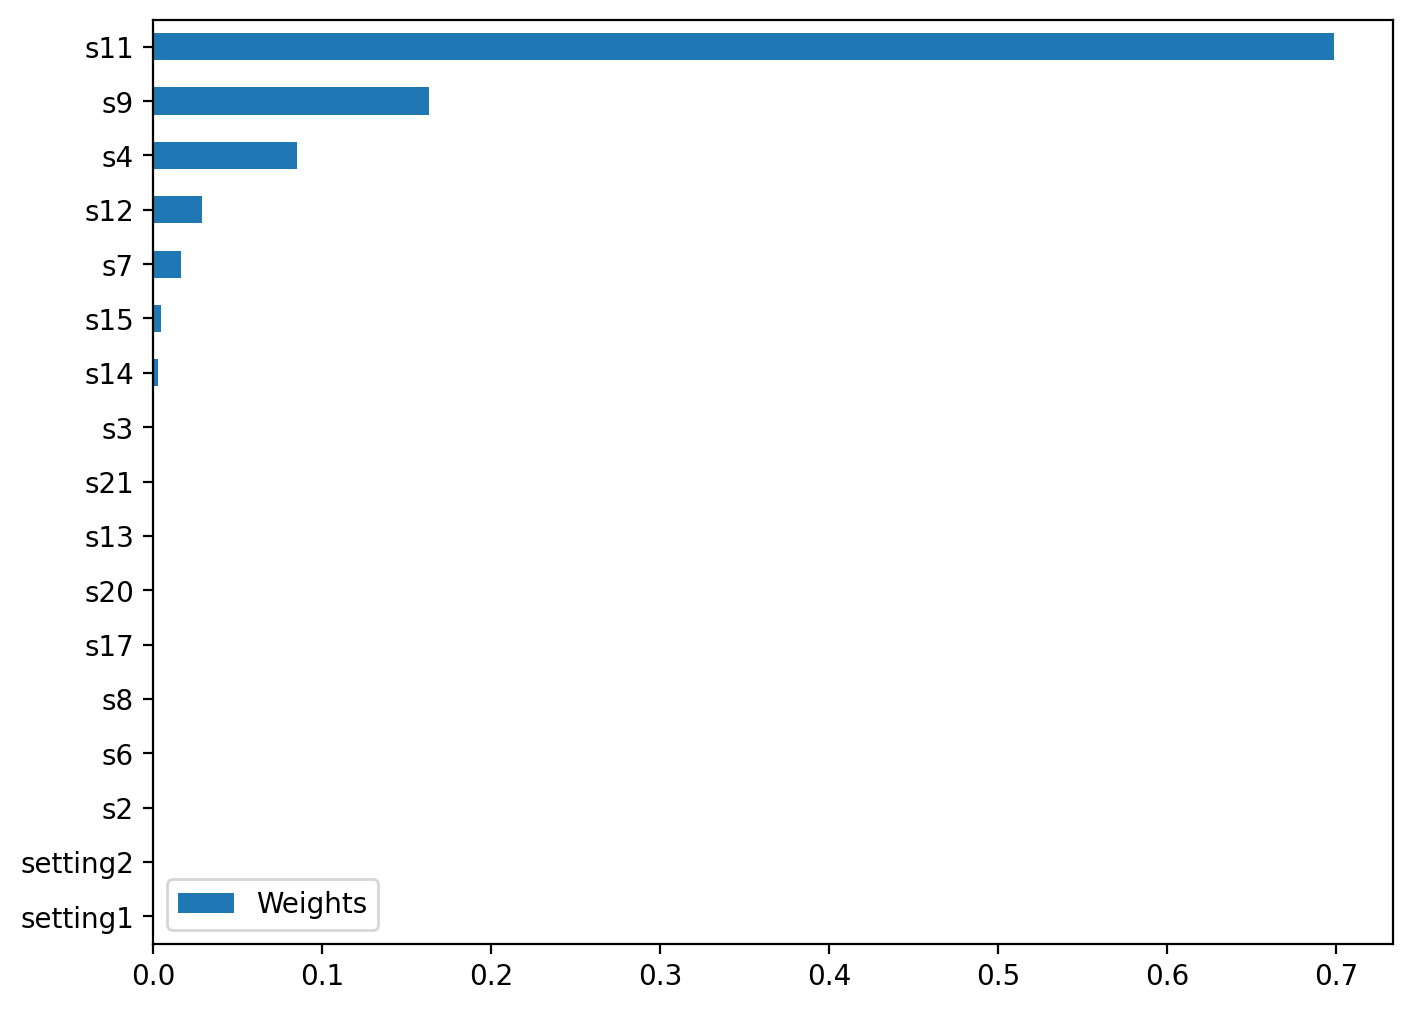

In [ ]:
# 트리 모델 특성 중요도 보기
# 특성 중요도: 트리를 나눌때 순도를 높이는데(잘 분류하는데) 많이 기여한 정도를 알려준다

plot_features_weights(X_train.columns, dtr.feature_importances_)

## 랜덤 포레스트 모델

- 결정 트리 모델의 성능을 개선한 앙상블 모델

MAE= 35.02753741600489
rmse= 46.36753908463462
max error= 217.11
R2= 0.3819123862378049


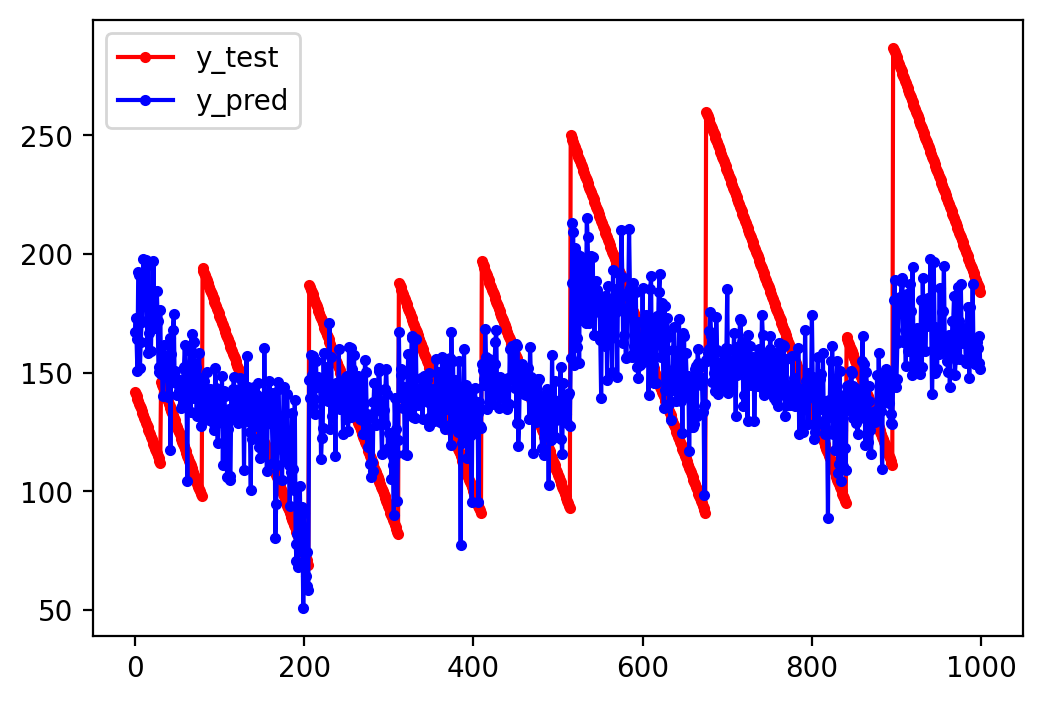

In [ ]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

rfr = RandomForestRegressor()
rfr.fit(X_train, y_train)
y_pred = rfr.predict(X_test)
show_regression_result(y_test, y_pred, 1000)

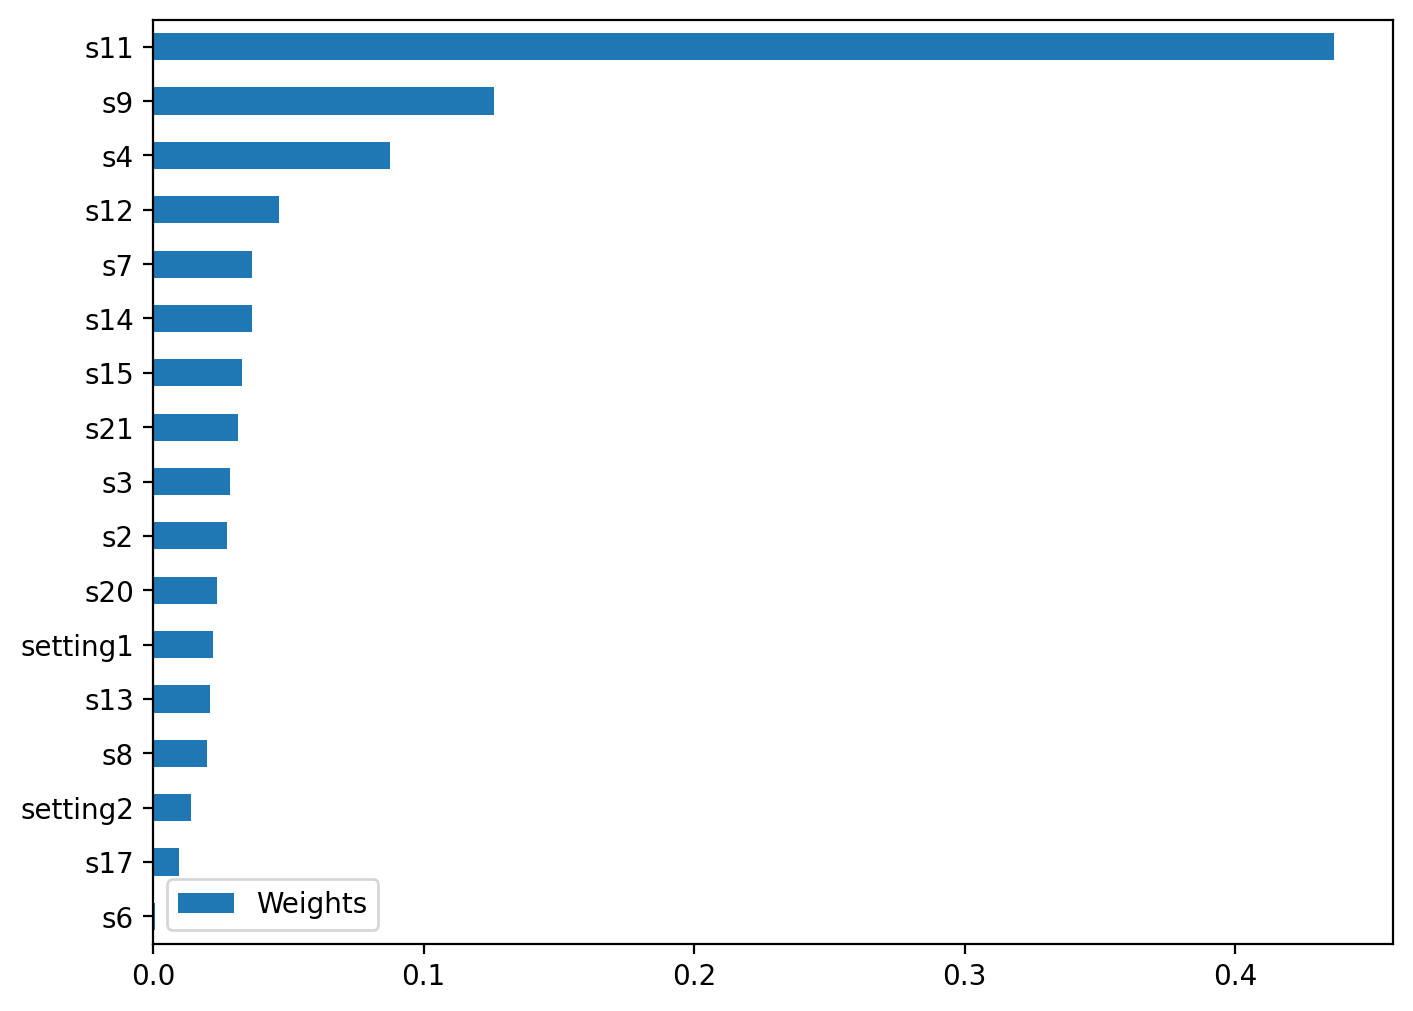

In [ ]:
# 랜덤 포레스트 모델의 특성 중요도 보기
plot_features_weights(X_train.columns, rfr.feature_importances_)

> 🆕 **[2026 보강]** 설명가능 AI (XAI) — SHAP로 RUL 예측 근거 설명

LSTM 같은 딥러닝 모델은 XAI에 DeepExplainer·Integrated Gradients가 필요합니다. 여기서는 같은 센서 데이터로 학습한 **트리 회귀 모델(rfr)** 에 SHAP을 적용해, **어떤 센서가 잔여수명(RUL) 예측에 기여하는지**를 해석합니다. 이 근거는 예지보수 의사결정의 감사추적에 첨부할 수 있습니다. (Part 5 · XAI 연계)

In [ ]:
# 🆕 [2026 보강] XAI(SHAP)로 RUL 예측 근거 설명하기
!pip install shap -q
import shap
explainer = shap.TreeExplainer(rfr)        # 트리 기반 RUL 회귀 모델
sv = explainer.shap_values(X_test)
shap.summary_plot(sv, X_test, plot_type='bar', show=True)   # 센서별 평균 기여도
shap.summary_plot(sv, X_test, show=True)                    # 샘플별 분포

## 부스팅 모델

- 결정 트리를 순차적으로 적용한 앙상블 모델
- 랜덤 포레스트는 병렬적으로 적용한 것임

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002830 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2837
[LightGBM] [Info] Number of data points in the train set: 20631, number of used features: 17
[LightGBM] [Info] Start training from score 107.807862
MAE= 34.57235201392281
rmse= 46.09395895217475
max error= 214.27562597739532
R2= 0.38918461326031417


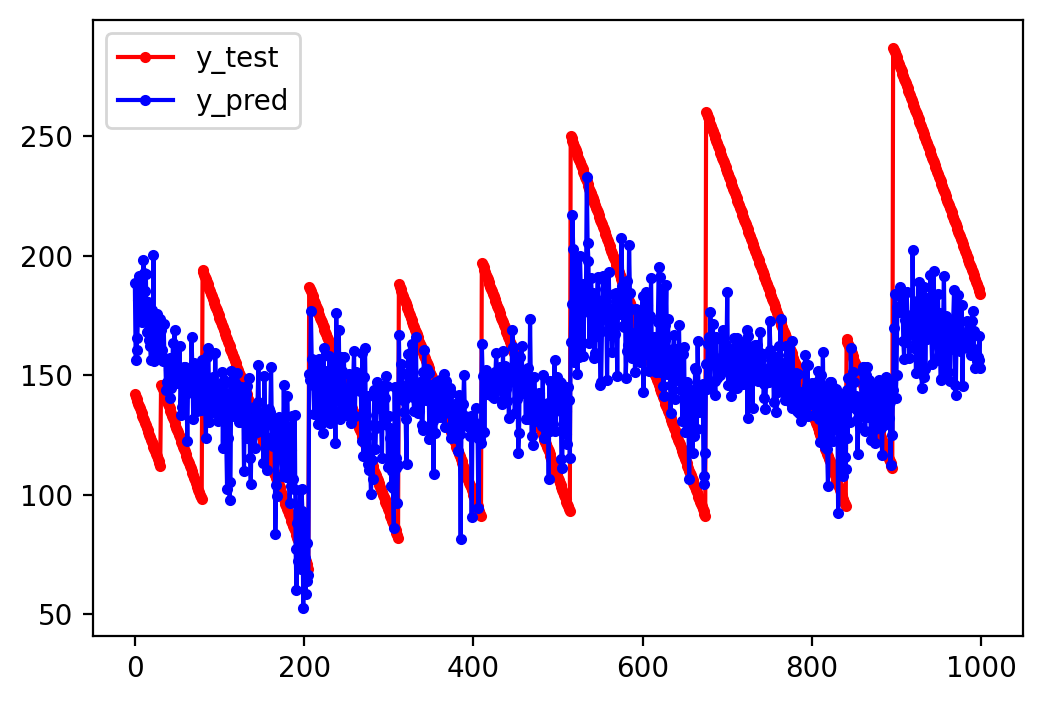

In [ ]:
from lightgbm import LGBMClassifier, LGBMRegressor

lgbm_r = LGBMRegressor()
lgbm_r.fit(X_train, y_train)
y_pred = lgbm_r.predict(X_test)
show_regression_result(y_test, y_pred,1000)

# 분류 모델

- 특정 기간 내에 장애가 발생할지를 이진 분류로 예측하는 모델

- X는 그대로 사용하고 y 값을 분류용 label로 변경한다

In [ ]:
y_train_c = df['label']
y_test_c = test_df['label']

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

def show_clf_result(y_test, y_pred):
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

## 선형 모델

In [ ]:
dtc = DecisionTreeClassifier(max_depth=5)
dtc.fit(X_train, y_train_c)
y_pred = dtc.predict(X_test)
show_clf_result(y_test_c, y_pred)

[[12705    59]
 [  152   180]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     12764
           1       0.75      0.54      0.63       332

    accuracy                           0.98     13096
   macro avg       0.87      0.77      0.81     13096
weighted avg       0.98      0.98      0.98     13096



## 트리 모델

In [ ]:
## 결정 트리를 이용한 이진 분류
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

for depth in range(1,20):
    dtc = DecisionTreeClassifier(max_depth=depth)
    dtc.fit(X_train, y_train_c)
    print(depth, dtc.score(X_test, y_test_c))

1 0.9746487477092242
2 0.9818265119120342
3 0.982895540623091
4 0.9828191814294441
5 0.9838882101405009
6 0.9835827733659133
7 0.9830482590103848
8 0.9838882101405009
9 0.9832773365913255
10 0.9822846670739157
11 0.9815210751374466
12 0.9805284056200366
13 0.9797648136835675
14 0.9791539401343922
15 0.9792302993280391
16 0.9774740378741601
17 0.9779321930360415
18 0.9772449602932193
19 0.976557727550397


In [ ]:
dtc = DecisionTreeClassifier(max_depth=5)
dtc.fit(X_train, y_train_c)
y_pred = dtc.predict(X_test)
show_clf_result(y_test_c, y_pred)

[[12705    59]
 [  152   180]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     12764
           1       0.75      0.54      0.63       332

    accuracy                           0.98     13096
   macro avg       0.87      0.77      0.81     13096
weighted avg       0.98      0.98      0.98     13096



- support는 레이블 별 샘플수
- macro 평균은 성능평가 점수들을 단순히 산술평균을 구한 것
- weighted 평균은 샘플의 갯수를 고려하여 가중평균을 구한 것

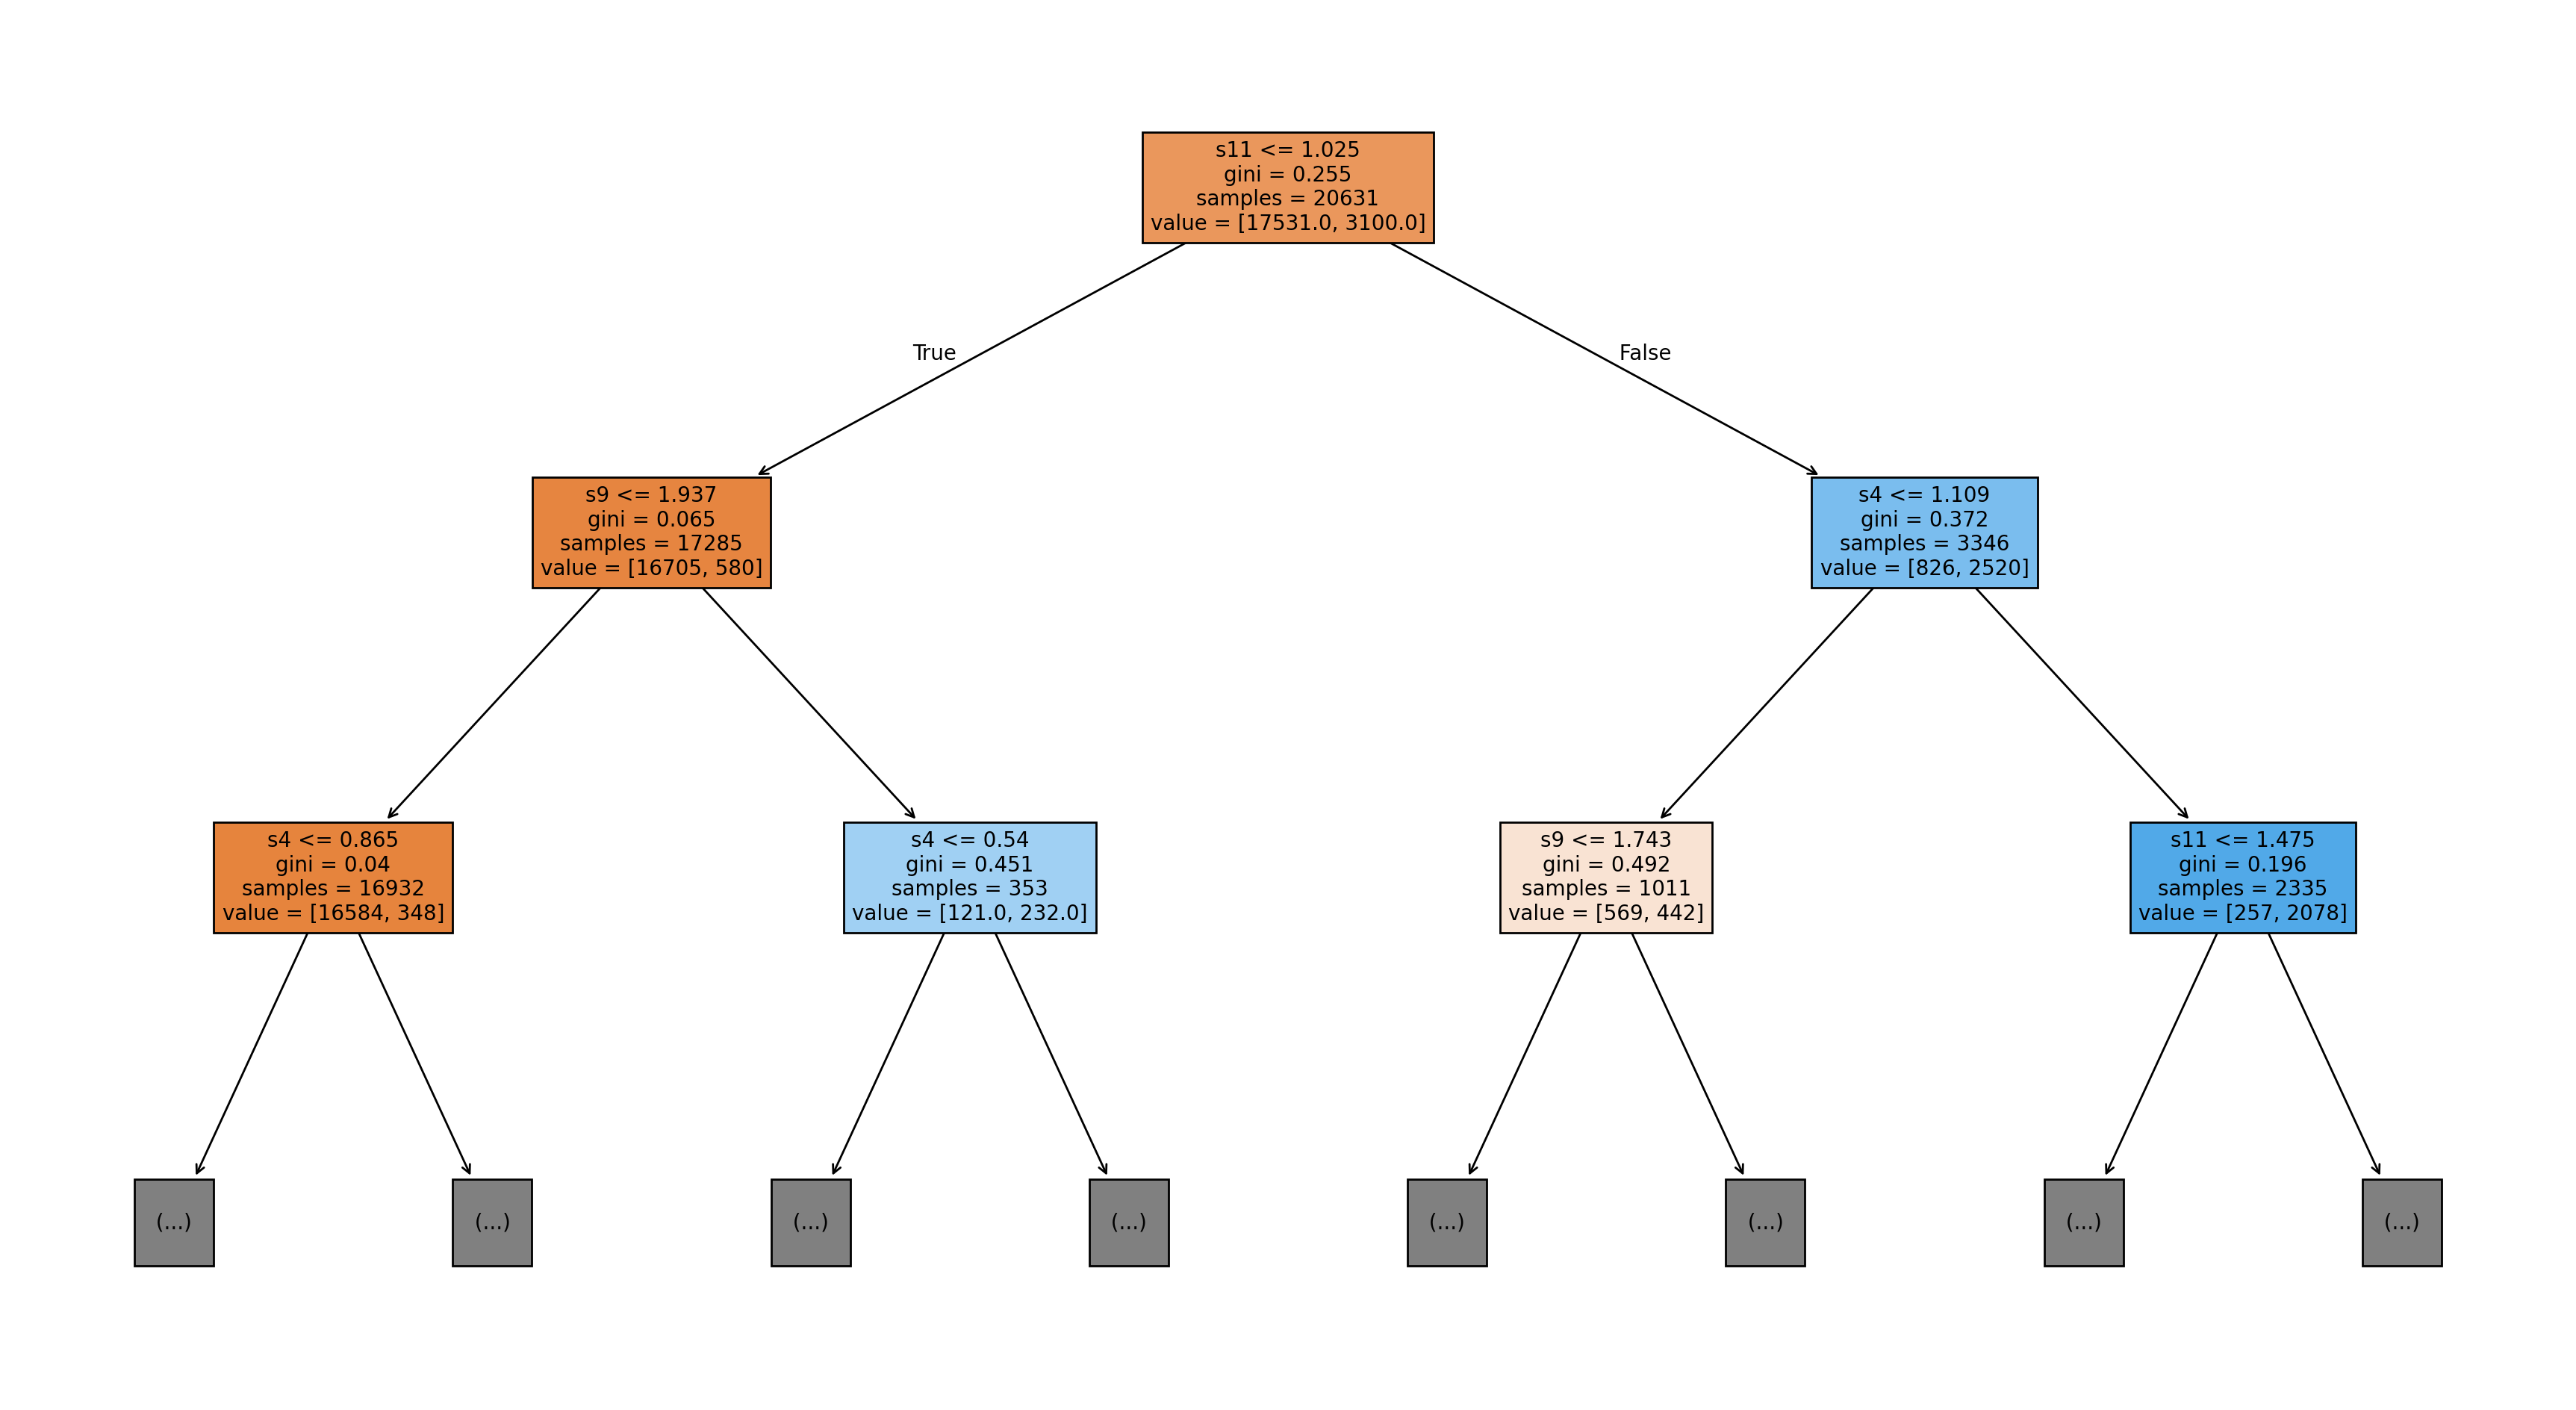

In [ ]:
# 트리 그리기

from sklearn import tree

plt.figure(figsize=(22,12))

tree.plot_tree(dtc, fontsize=10,
              feature_names=list(X_train.columns),
              filled=True,
              impurity=True,
              max_depth=2)
plt.show()

In [ ]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train_c)
y_pred = rfc.predict(X_test)

In [ ]:
show_clf_result(y_test_c, y_pred)

[[12714    50]
 [  124   208]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     12764
           1       0.81      0.63      0.71       332

    accuracy                           0.99     13096
   macro avg       0.90      0.81      0.85     13096
weighted avg       0.99      0.99      0.99     13096



## 부스팅 모델

In [ ]:
lgbm_c = LGBMClassifier()
lgbm_c.fit(X_train, y_train_c)
y_pred = lgbm_c.predict(X_test)
show_clf_result(y_test_c, y_pred)

[LightGBM] [Info] Number of positive: 3100, number of negative: 17531
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003252 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2837
[LightGBM] [Info] Number of data points in the train set: 20631, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.150259 -> initscore=-1.732569
[LightGBM] [Info] Start training from score -1.732569
[[12714    50]
 [  125   207]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     12764
           1       0.81      0.62      0.70       332

    accuracy                           0.99     13096
   macro avg       0.90      0.81      0.85     13096
weighted avg       0.99      0.99      0.99     13096



# 신경망 모델

- LSTM 사용
- LSTM 윈도우를 충분히 크게 잡으면 윈도우 내의 중요한 신호를 파악하여 사용할 수 있다
- LSTM 신경망은 (samples, time steps, features) 구조의 입력를 필요로 한다
- colab에서 실행해야 함


## 💻 [셀 설명] LSTM — 시간 흐름을 기억하는 신경망

**LSTM(Long Short-Term Memory)**은 시계열 데이터를 처리하기 위해 특별히 설계된 신경망입니다.

### LSTM의 핵심 아이디어
```
일반 신경망: 현재 입력만 보고 판단
LSTM:        과거 50 사이클의 흐름 + 현재 입력 → 판단
```
- **"50 사이클 전부터 온도가 서서히 오르고 있다"** → LSTM이 이런 점진적 변화(Drift)를 감지

### 제약 설비에서 LSTM이 중요한 이유
| 전통 방법(임계값 초과 경보) | LSTM |
|--------------------------|------|
| "지금 온도가 40°C 초과됨!" | "지난 50배치 동안 온도가 꾸준히 오르는 추세 → 다음 20배치 내 임계값 초과 예측" |
| 이미 문제 발생 후 감지 | **문제 발생 전 예측** |
| FP(오경보) 많음 | FP 적음 |

### GMP SPC(통계적 공정 관리)와 비교
- **전통 SPC**: Shewhart 관리도, Western Electric 규칙 → 단순 임계값 기반
- **LSTM 기반 예측**: 복잡한 시간적 패턴 학습 → PAT의 진화된 형태
- **FDA ICH Q8**: "향상된 공정 이해(Enhanced Process Understanding)" = LSTM이 제공하는 것


## 시퀀스를 n_steps 크기로 나누는 함수

- (주의) 아래 함수는 마지막 샘플은 포함하지 않는다
- 현재 데이터로 현재를 예측하는 것이 맞는지는 응용에 따라서 점검해야 한다

In [ ]:
def split_seq(sequence, n_steps):
  x = []
  for i in range(len(sequence)- n_steps):
    x.append(sequence[i:i+ n_steps])
  return np.array(x)

In [ ]:
# 예제
# 특성수가 3인 시계열 데이터를 스텝수가 4가 되도록 3차원 어레이로 만드는 함수

x = np.arange(30).reshape(-1,3)
print(x)
inp = split_seq(x,4)
print('LSTM 모델 입력용 데이터:',inp.shape)
inp

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]
 [15 16 17]
 [18 19 20]
 [21 22 23]
 [24 25 26]
 [27 28 29]]
LSTM 모델 입력용 데이터: (6, 4, 3)


array([[[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]],

       [[ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14]],

       [[ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17]],

       [[ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17],
        [18, 19, 20]],

       [[12, 13, 14],
        [15, 16, 17],
        [18, 19, 20],
        [21, 22, 23]],

       [[15, 16, 17],
        [18, 19, 20],
        [21, 22, 23],
        [24, 25, 26]]])

## 입력 시퀀스 만들기

In [ ]:
# 주의: 같은 id인 엔진의 데이터로만 학습데이터 스텝을 만들어야 한다
n_steps = 50
res = []
for id in df['id'].unique():
  res.append(split_seq(df[df['id']==id][features], n_steps))
seq_array = np.concatenate(res)
seq_array.shape

(15631, 50, 17)

In [ ]:
# 각 동일한 엔진에 대한 데이터를 50개씩 사용해야 하므로 샘플수가 줄어들었다
# 50개 샘플이 두개의 엔진에 걸쳐 있는 데이터는 버림
df.shape

(20631, 21)

## 회귀 모델

In [ ]:
# 회귀 레이블 얻기
res2 = []
label = ["RUL"]
for id in df['id'].unique():
  res2.append(df[df['id']==id][label][n_steps:len(df)])
label_array = np.concatenate(res2)
label_array.shape

(15631, 1)

In [ ]:
import keras
from keras import Sequential
from keras.layers import Dropout, LSTM, Dense, Activation

nb_features = seq_array.shape[2]
nb_out = label_array.shape[1]

model = Sequential()

model.add(LSTM(
         input_shape=(n_steps, nb_features), # 스텝 수, 특성 수
         units=100))                          # 셀의 수

model.add(Dense(1)) # 1
model.add(Activation("linear"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        47,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,301 (184.77 KB)

 Trainable params: 47,301 (184.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='mean_squared_error', optimizer='rmsprop',metrics=['mse'])

history = model.fit(seq_array, label_array, epochs=100, batch_size=50, validation_split=0.1, verbose=2,
          callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=3, verbose=0, mode='min')])

print(history.history.keys())

Epoch 1/100
282/282 - 4s - 16ms/step - loss: 6484.9790 - mse: 6484.9790 - val_loss: 7256.4360 - val_mse: 7256.4360
Epoch 2/100
282/282 - 4s - 13ms/step - loss: 3734.1995 - mse: 3734.1995 - val_loss: 4528.1265 - val_mse: 4528.1270
Epoch 3/100
282/282 - 2s - 8ms/step - loss: 2094.0752 - mse: 2094.0752 - val_loss: 2775.2073 - val_mse: 2775.2073
Epoch 4/100
282/282 - 2s - 6ms/step - loss: 1216.8368 - mse: 1216.8367 - val_loss: 1803.8745 - val_mse: 1803.8744
Epoch 5/100
282/282 - 2s - 6ms/step - loss: 805.4394 - mse: 805.4394 - val_loss: 1364.3243 - val_mse: 1364.3243
Epoch 6/100
282/282 - 2s - 5ms/step - loss: 649.4324 - mse: 649.4324 - val_loss: 1175.5670 - val_mse: 1175.5670
Epoch 7/100
282/282 - 2s - 5ms/step - loss: 566.6696 - mse: 566.6696 - val_loss: 1208.4319 - val_mse: 1208.4319
Epoch 8/100
282/282 - 2s - 5ms/step - loss: 506.7056 - mse: 506.7056 - val_loss: 1582.3494 - val_mse: 1582.3494
Epoch 9/100
282/282 - 2s - 5ms/step - loss: 443.6671 - mse: 443.6671 - val_loss: 1128.6031 - v

In [ ]:
y_pred = model.predict(seq_array,verbose=1, batch_size=50)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


MAE= 11.860626447678191
rmse= 19.63370520677082
max error= [163.60163116]
R2= 0.8819428086280823


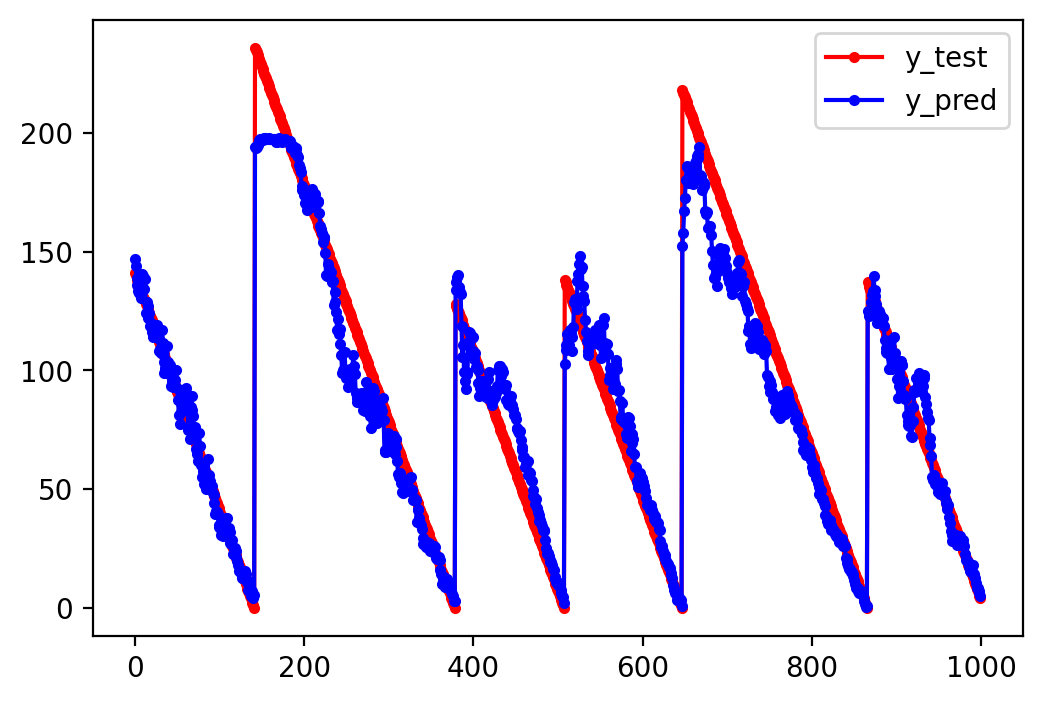

In [ ]:
show_regression_result(label_array, y_pred,1000)

- 테스트 데이터의 각 엔진별 마지막 50 샘플을 입력으로 사용한다
- 마지막 샘플수가 50보다 작은 경우는 테스트할 수 없다

In [ ]:
sequence_cols = features
sequence_length = 50
seq_array_test_last = [test_df[test_df['id']==id][sequence_cols].values[-sequence_length:]
                       for id in test_df['id'].unique() if len(test_df[test_df['id']==id]) >= sequence_length]

seq_array_test_last = np.asarray(seq_array_test_last).astype(np.float32)
seq_array_test_last.shape

(93, 50, 17)

In [ ]:
# test_df의 마지막 샘플의 크기가 50 이상인지를 확인
y_mask = [len(test_df[test_df['id']==id]) >= sequence_length for id in test_df['id'].unique()]

In [ ]:
len(y_mask), np.array(y_mask).sum()

(100, np.int64(93))

- 회귀 레이블 얻기

In [ ]:
y_test = test_df.groupby('id')['RUL'].nth(-1)[y_mask].values
y_test

array([ 69,  82,  91,  93,  91,  95, 111,  96,  97, 124,  95,  83,  84,
        50,  28,  87,  16,  57, 113,  20, 119,  66,  97,  90, 115,   8,
        48, 106,   7,  11,  19,  21,  50,  28,  18,  10,  59, 109, 114,
        47, 135,  92,  21,  79, 114,  29,  26,  97, 137,  15, 103,  37,
       114, 100,  21,  54,  72,  28, 128,  14,  77,   8, 121,  94, 118,
        50, 131, 126, 113,  10,  34, 107,  63,  90,   8,   9, 137,  58,
        89, 116, 115, 136,  28,  38,  20,  85,  55, 128, 137,  82,  59,
       117,  20])

In [ ]:
label_array_test_last = test_df.groupby('id')['RUL'].nth(-1)[y_mask].values
label_array_test_last = label_array_test_last.reshape(label_array_test_last.shape[0],1).astype(np.float32)
label_array_test_last.shape

(93, 1)

In [ ]:
print(seq_array_test_last.shape)
print(label_array_test_last.shape)

(93, 50, 17)
(93, 1)


In [ ]:
y_pred = model.predict(seq_array_test_last)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


MAE= 16.083708998977496
rmse= 25.931816739645488
max error= 126.00529479980469
R2= 0.6005277633666992


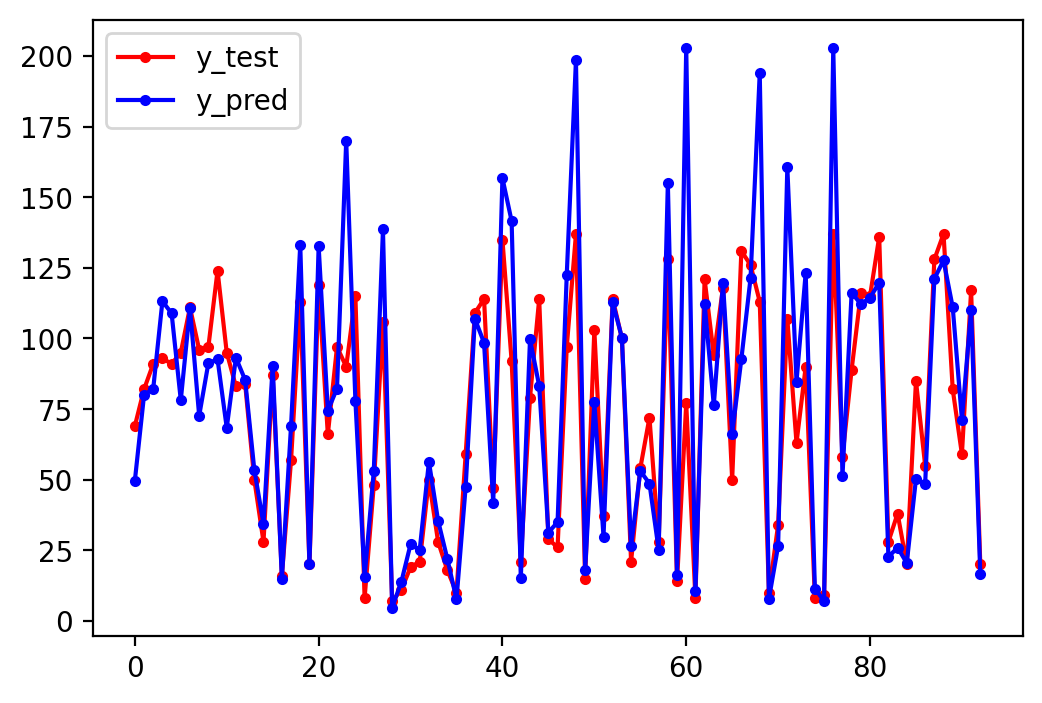

In [ ]:
# 회귀 성능
show_regression_result(y_test, y_pred.ravel(),100)

## 이진 분류 모델

In [ ]:
# 이진분류 레이블 얻기
res2 = []
label = ["label"]
for id in df['id'].unique():
  res2.append(df[df['id']==id][label][n_steps:len(df)])
label_array = np.concatenate(res2)
label_array.shape

(15631, 1)

- softmax 대신 sigmoid를 사용할 수 있다 (이진 분류시)
- loss='binary_crossentropy'로 지정해야 한다

In [ ]:
nb_features = seq_array.shape[2]
nb_out = label_array.shape[1]

model = Sequential()

model.add(LSTM(
         input_shape=(n_steps, nb_features), # 스텝 수, 특성 수
         units=100))                          # 셀의 수

model.add(Dense(units=nb_out, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 100)            │        47,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,301 (184.77 KB)

 Trainable params: 47,301 (184.77 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
seq_array.shape, label_array.shape

((15631, 50, 17), (15631, 1))

In [ ]:
%%time
# fit the network
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(seq_array, label_array, epochs=100, batch_size=200, validation_split=0.1, verbose=1,
          callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=0, mode='auto')])

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9020 - loss: 0.2170 - val_accuracy: 0.9290 - val_loss: 0.1512
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9694 - loss: 0.0781 - val_accuracy: 0.9552 - val_loss: 0.1093
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9733 - loss: 0.0642 - val_accuracy: 0.9623 - val_loss: 0.0961
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9779 - loss: 0.0556 - val_accuracy: 0.9661 - val_loss: 0.0714
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9782 - loss: 0.0525 - val_accuracy: 0.9674 - val_loss: 0.0743
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9803 - loss: 0.0469 - val_accuracy: 0.9546 - val_loss: 0.0973
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9827 - loss: 0.0421 - val_accuracy: 0.9629 - val_loss: 0.0794
CPU times: user 6.41 s, sys: 537 ms, total: 6.95 s
Wall time: 6.4 s


In [ ]:
label_array_test_last = test_df.groupby('id')['label'].nth(-1)[y_mask].values
label_array_test_last = label_array_test_last.reshape(label_array_test_last.shape[0],1)
label_array_test_last.shape

(93, 1)

In [ ]:
# 이진 분류 확률을 얻는다
y_pred_test = model.predict(seq_array_test_last)
show_clf_result(label_array_test_last, y_pred_test > 0.5)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[67  1]
 [ 3 22]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        68
           1       0.96      0.88      0.92        25

    accuracy                           0.96        93
   macro avg       0.96      0.93      0.94        93
weighted avg       0.96      0.96      0.96        93



## 📝 정리: 예지보전 구현 로드맵

### 1단계: 데이터 수집 전략
```
동결건조기 → IoT 센서(21개) → SCADA/MES → 데이터 레이크 → RUL 예측 모델
```

### 2단계: RUL 레이블 전략
| 방법 | 설명 | 적합한 상황 |
|------|------|-------------|
| 선형 RUL | 고장까지 선형 감소 | 초기 모델, 단순한 열화 |
| 비선형 RUL | 가속 열화 구간 반영 | 실제 기계 마모 |
| 이진 분류 | 임계값 기반 경보 | 현장 알람 시스템 |

### GMP 규제 고려사항
- **IQ/OQ/PQ:** AI 예지보전 시스템도 기기 적격성 평가 필요
- **21 CFR Part 11:** 모든 예측 결과와 정비 조치 기록 유지
- **CAPA:** 반복 고장 → AI 모델 재학습 절차 문서화

---
## ✅ 핵심 요약

| 항목 | 내용 |
|------|------|
| **GMP 적용** | EU GMP Annex 1 · GAMP 5 — 계획적 설비 관리 |
| **AI 기법** | LSTM · Random Forest · RUL 회귀 · 이진 분류(Unsafe) |
| **핵심 성과** | 동결건조기 RUL 예측 · 고장 임박 배치 조기 경보 |
| **다음 단계** | 가상 데이터 → 예제 9·10(실제 발효 데이터)으로 종합 적용 |

> 💡 **기억할 한 줄**: "예지보수 AI 1개 모델의 ROI = (예방된 배치 손실 금액) / (개발 비용) — 제약 업계에서 즉각 계산 가능."